# Results from the ML model with `GenMET_px`, `GenMET_py` as targets and `response` configuration

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import os
import shap
import sys

sys.path.append("../../MET_models/")
from MET_pxpy_testing import load_model_and_scaler

/home/matilde/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "
/usr/lib/python3/dist-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"
/home/matilde/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
E0000 00:00:1784182518.813774  769486 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plu

In [2]:
def _pt(px, py):
    return np.sqrt(px**2 + py**2)

In [3]:
def load_predictions(event: str):
    """
        Loads MET pred, MET reco and GenMET from the parquet
        saved by the prediction on dataset.
    """
    parquet_path = f"predictions_testing_pxpy_{event}.parquet"

    if not os.path.exists(parquet_path):
        raise FileNotFoundError(f"Parquet not found: {parquet_path}")

    df = pd.read_parquet(parquet_path)

    def _get(col):
        if col in df.columns:
            return df[col].to_numpy()
        print(f"  [WARNING] Column '{col}' not found.")
        return None

    pred_px = _get("pred_MET_px");  pred_py = _get("pred_MET_py")
    true_px = _get("GenMET_px");    true_py = _get("GenMET_py")
    reco_px = _get("MET_px");       reco_py = _get("MET_py")

    pred_pt = _get("pred_MET_pt") if "pred_MET_pt" in df.columns else (
              _pt(pred_px, pred_py) if pred_px is not None else None)
    true_pt = _get("GenMET_pt")   if "GenMET_pt"   in df.columns else (
              _pt(true_px, true_py) if true_px is not None else None)
    reco_pt = _get("MET_pt")      if "MET_pt"      in df.columns else (
              _pt(reco_px, reco_py) if reco_px is not None else None)

    return (pred_px, pred_py, pred_pt,
            true_px, true_py, true_pt,
            reco_px, reco_py, reco_pt)

In [4]:
def _compute_metrics(pred_px, pred_py, pred_pt,
                     true_px, true_py, true_pt,
                     reco_px, reco_py, reco_pt,
                     event: str):
    """
        Prints MSE/RMSE/MAE/R² for px, py and pt,
        both for reco vs Gen and predicted vs Gen,
        plus absolute and relative improvements.
    """
    components = [
        ("px", pred_px, true_px, reco_px),
        ("py", pred_py, true_py, reco_py),
        ("pt", pred_pt, true_pt, reco_pt),
    ]

    for comp, pred, true, reco in components:
        print(f"\n{comp.upper()} - {event}")

        rmse_reco = np.sqrt(mean_squared_error(true, reco))
        mae_reco  = mean_absolute_error(true, reco)
        r2_reco   = r2_score(true, reco)
        std_reco  = np.std(reco - true)
        print(f"Reconstruction performance for {event}:")
        print(f"    RMSE = {rmse_reco:.4f} GeV")
        print(f"    MAE  = {mae_reco:.4f} GeV")
        print(f"    R²   = {r2_reco:.4f}")
        print(f"    Std(residuals) = {std_reco:.4f} GeV")

        rmse_pred = np.sqrt(mean_squared_error(true, pred))
        mae_pred  = mean_absolute_error(true, pred)
        r2_pred   = r2_score(true, pred)
        std_pred  = np.std(pred - true)
        print(f"ML model performance for {event}:")
        print(f"    RMSE = {rmse_pred:.4f} GeV")
        print(f"    MAE  = {mae_pred:.4f} GeV")
        print(f"    R²   = {r2_pred:.4f}")
        print(f"    Std(residuals) = {std_pred:.4f} GeV")
        
        DELTA_rmse = rmse_reco - rmse_pred
        DELTA_mae  = mae_reco  - mae_pred
        DELTA_r2   = r2_pred   - r2_reco
        DELTA_std  = std_reco - std_pred

        pct_rmse = DELTA_rmse / rmse_reco * 100
        pct_mae  = DELTA_mae  / mae_reco  * 100
        pct_r2   = DELTA_r2   / abs(r2_reco) * 100 if r2_reco != 0 else float("nan")
        pct_std  = DELTA_std / std_reco * 100
        print(f"Performance improvement for {event}:")
        print(f"    DELTA_RMSE = {DELTA_rmse:+.4f} GeV ({pct_rmse:+.2f}%)")
        print(f"    DELTA_MAE  = {DELTA_mae:+.4f} GeV ({pct_mae:+.2f}%)")
        print(f"    DELTA_R²   = {DELTA_r2:+.4f}     ({pct_r2:+.2f}%)")
        print(f"    DELTA_STD  = {DELTA_std:.4f}    {pct_std:+.2f}%")
    return

In [ ]:
def _plot_fold_learning_curves(df_folds):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f"CV Fold Learning Curves", fontsize=13, fontweight="bold")
    colors = ["tab:blue", "tab:orange", "tab:green"]

    for fh in df_folds.groupby("fold"):
        fold_idx, df = fh
        c = colors[(fold_idx - 1) % len(colors)]
        axes[0].plot(df["epoch"], df["loss"],     color=c, lw=1.5, label=f"Train fold {fold_idx}")
        axes[0].plot(df["epoch"], df["val_loss"], color=c, lw=1.5, linestyle="--", label=f"Val fold {fold_idx}")
        axes[1].plot(df["epoch"], df["loss"].pow(0.5),     color=c, lw=1.5, label=f"Train fold {fold_idx}")
        axes[1].plot(df["epoch"], df["val_loss"].pow(0.5), color=c, lw=1.5, linestyle="--", label=f"Val fold {fold_idx}")

    for ax, ylabel, title in zip(axes, ["", ""], ["MSE Loss", "RMSE"]):
        ax.set_title(title, fontsize=11)
        ax.set_xlabel("Epoch", fontsize=10)
        ax.set_ylabel(ylabel, fontsize=10)
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()
    return

In [ ]:
def _plot_learning_curves(df_lc):
    epochs  = range(1, len(df_lc) + 1)
    has_val = "val_loss" in df_lc.columns
    has_mse = "mse" in df_lc.columns

    fig, axes = plt.subplots(1, 2 if has_mse else 1, figsize=(14 if has_mse else 7, 5))
    if not has_mse:
        axes = [axes]
    fig.suptitle(f"Retraining Learning Curves", fontsize=13, fontweight="bold")

    # Loss
    axes[0].plot(epochs, df_lc["loss"], color="red", lw=1.5, label="Train loss")
    if has_val:
        axes[0].plot(epochs, df_lc["val_loss"], color="blue", lw=1.5, label="Val loss")
    axes[0].set_title("MSE Loss", fontsize=11)
    axes[0].set_xlabel("Epoch", fontsize=10)
    axes[0].set_ylabel("", fontsize=10)
    axes[0].legend(fontsize=9)
    axes[0].grid(alpha=0.3)

    # RMSE
    if has_mse:
        axes[1].plot(epochs, df_lc["mse"].pow(0.5), color="red", lw=1.5, label="Train RMSE")
        if has_val:
            axes[1].plot(epochs, df_lc["val_mse"].pow(0.5), color="blue", lw=1.5, label="Val RMSE")
        axes[1].set_title("RMSE", fontsize=11)
        axes[1].set_xlabel("Epoch", fontsize=10)
        axes[1].set_ylabel("", fontsize=10)
        axes[1].legend(fontsize=9)
        axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    print(f"Retraining learning curves:")
    print(f"    Epochs run       : {len(df_lc)}")
    print(f"    Final train loss : {df_lc['loss'].iloc[-1]:.4f}")
    if has_val:
        print(f"    Final val loss   : {df_lc['val_loss'].iloc[-1]:.4f}")
        print(f"    Best val loss    : {df_lc['val_loss'].min():.4f}  "
              f"(epoch {df_lc['val_loss'].idxmin() + 1})")
    return

In [7]:
def _scatter_one(ax, x, y, xlabel, ylabel, title, color):
    """
        Single scatter panel with identity line and annotation.
    """
    ax.scatter(x, y, alpha=0.3, s=8, color=color, rasterized=True)
    lims = [min(x.min(), y.min()), max(x.max(), y.max())]
    ax.plot(lims, lims, "r--", lw=1.2, label="y = x")
    r2   = r2_score(x, y)
    rmse = np.sqrt(mean_squared_error(x, y))
    ax.text(0.05, 0.92, f"RMSE = {rmse:.2f} GeV\n$R^2$ = {r2:.4f}",
            transform=ax.transAxes, fontsize=9,
            bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.7))
    ax.set_xlabel(xlabel, fontsize=10)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_title(title, fontsize=10, fontweight="bold")
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
    return

In [8]:
def _scatterplots(pred_px, pred_py, pred_pt,
                  true_px, true_py, true_pt,
                  reco_px, reco_py, reco_pt,
                  event: str):
    """
        Layout:
        - 3 rows = px / py / pt
        - 2 cols = Reco vs Gen | Predicted vs Gen
    """
    fig, axes = plt.subplots(3, 2, figsize=(13, 17))
    fig.suptitle(f"Scatter plots - {event}", fontsize=14, fontweight="bold")

    rows = [
        ("px", true_px, pred_px, reco_px, "GenMET_px [GeV]",
         "Predicted MET_px [GeV]", "Reconstructed MET_px [GeV]", "steelblue"),
        ("py", true_py, pred_py, reco_py, "GenMET_py [GeV]",
         "Predicted MET_py [GeV]", "Reconstructed MET_py [GeV]", "darkorange"),
        ("pt", true_pt, pred_pt, reco_pt, "GenMET_pt [GeV]",
         "Predicted MET_pt [GeV]", "Reconstructed MET_pt [GeV]", "seagreen"),
    ]

    for row_i, (comp, true, pred, reco,
                xlabel, ylabel_pred, ylabel_reco, color) in enumerate(rows):
        _scatter_one(axes[row_i, 0], true, reco,
                     xlabel, ylabel_reco,
                     f"Reconstructed MET vs GenMET - {comp}", color)
        _scatter_one(axes[row_i, 1], true, pred,
                     xlabel, ylabel_pred,
                     f"Predicted MET vs GenMET - {comp}", color)

    plt.tight_layout()
    plt.show()
    return

In [9]:
def _response_and_residual_plots(pred_px, pred_py, pred_pt,
                    true_px, true_py, true_pt,
                    reco_px, reco_py, reco_pt,
                    event: str):
    """
        Per component (px, py) and module (pt) response and residual plots.
        For px e py the pred/true response can be negative;
        For pt the pred/true response is always positive (mask > 0)
    """
    components = [
        ("px", pred_px, true_px, reco_px, 0),
        ("py", pred_py, true_py, reco_py, 0),
        ("pt", pred_pt, true_pt, reco_pt, 0.1),
    ]
    fig, axes = plt.subplots(3, 2, figsize=(14, 15))
    fig.suptitle(f"Response and Residuals - {event}", fontsize=14, fontweight="bold")
    for row_i, (comp, pred, true, reco, min_true) in enumerate(components):
        # mask: avoid division by zero
        mask      = np.abs(true) > min_true
        resp_pred = pred[mask] / true[mask]
        resp_reco = reco[mask] / true[mask]
        res_pred  = pred[mask] - true[mask]
        res_reco  = reco[mask] - true[mask]

        mu_pred, sig_pred = resp_pred.mean(), resp_pred.std()
        mu_reco, sig_reco = resp_reco.mean(), resp_reco.std()

        # Left: response histogram
        ax_hist = axes[row_i, 0]
        if comp in ("px", "py"):
            # the response can be negative: bins centered on -1
            bins = np.linspace(-3, 5, 100)
        else:
            bins = np.linspace(0, 3, 80)
        ax_hist.hist(resp_pred, bins=bins, alpha=0.6, color="darkorange",
                     label=f"Pred ($\mu$={mu_pred:.2e}, $\sigma$={sig_pred:.2e})")
        ax_hist.hist(resp_reco, bins=bins, alpha=0.6, color="steelblue",
                     label=f"Reco ($\mu$={mu_reco:.2e}, $\sigma$={sig_reco:.2e})")
        ax_hist.axvline(1, color="red", ls="--", lw=1.2, label="ideal = 1")
        ax_hist.set_xlabel(f"MET {comp} / GenMET_{comp}", fontsize=11)
        ax_hist.set_ylabel("Events", fontsize=11)
        ax_hist.set_title(f"Response distribution - {comp}", fontsize=11)
        ax_hist.legend(fontsize=9)
        ax_hist.grid(alpha=0.3)

        # Right: residual histogram
        ax_res = axes[row_i, 1]
        bins_res = np.linspace(
            min(res_pred.min(), res_reco.min()),
            max(res_pred.max(), res_reco.max()),
            80
        )
        ax_res.hist(res_pred, bins=bins_res, alpha=0.6, color="darkorange",
                    label=f"Pred ($\mu$={res_pred.mean():.2f}, $\sigma$={res_pred.std():.2f})")
        ax_res.hist(res_reco, bins=bins_res, alpha=0.6, color="steelblue",
                    label=f"Reco ($\mu$={res_reco.mean():.2f}, $\sigma$={res_reco.std():.2f})")
        ax_res.axvline(0, color="red", ls="--", lw=1.2, label="ideal = 0")
        ax_res.set_xlabel(f"MET {comp} - GenMET_{comp} [GeV]", fontsize=11)
        ax_res.set_ylabel("Events", fontsize=11)
        ax_res.set_title(f"Residual distribution - {comp}", fontsize=11)
        ax_res.legend(fontsize=9)
        ax_res.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
    return

In [10]:
def _profile_histogram_residuals(pred_px, pred_py, pred_pt,
                                  true_px, true_py, true_pt,
                                  reco_px, reco_py, reco_pt,
                                  event: str,
                                  bin_width: float = 10.0,
                                  min_counts: int = 10,
                                  min_Gen: float = 50.0):
    """
        Profile histogram of the residuals (MET - GenMET) vs GenMET for px, py, pt.
    """
    fig, axes = plt.subplots(3, 2, figsize=(14, 15))
    fig.suptitle(f"Residual Profile Histogram - {event}",
                 fontsize=14, fontweight="bold")

    components = [
        ("px", true_px, pred_px, reco_px, None),
        ("py", true_py, pred_py, reco_py, None),
        ("pt", true_pt, pred_pt, reco_pt, min_Gen),
    ]

    print("Residual Profile Histogram specifics:")
    for row_i, (comp, true, pred, reco, mingen) in enumerate(components):

        # apply min_gen mask only for pt
        if mingen is not None:
            mask     = true > mingen
            true_m   = true[mask]
            pred_m   = pred[mask]
            reco_m   = reco[mask]
            print(f"  Excluding GenMET_{comp} <= {mingen} GeV: {(~mask).sum():,} events removed")
        else:
            true_m = true
            pred_m = pred
            reco_m = reco

        x_max  = np.ceil(true_m.max()  / bin_width) * bin_width
        x_min  = np.floor(true_m.min() / bin_width) * bin_width
        n_bins = int(round((x_max - x_min) / bin_width))
        bins        = np.linspace(x_min, x_max, n_bins + 1)
        bin_centers = 0.5 * (bins[:-1] + bins[1:])
        bin_indices = np.clip(np.digitize(true_m, bins) - 1, 0, n_bins - 1)
        counts_true = np.array([(bin_indices == i).sum() for i in range(n_bins)])

        valid_mask      = counts_true >= min_counts
        first_valid_bin = np.min(np.where(valid_mask)[0])
        last_valid_bin  = np.max(np.where(valid_mask)[0])
        x_plot_min      = bins[first_valid_bin]
        x_plot_max      = bins[last_valid_bin + 1]

        print(f"    [{comp}] bin_width={bin_width} GeV | "
              f"range [{x_plot_min:.0f}, {x_plot_max:.0f}] GeV | "
              f"n_bins={n_bins}")

        arrays  = {f"pred {comp}": pred_m, f"reco {comp}": reco_m}
        colors  = {f"pred {comp}": "darkorange", f"reco {comp}": "steelblue"}
        markers = {f"pred {comp}": "o",           f"reco {comp}": "^"}

        for label, arr in arrays.items():
            residual = arr - true_m
            means  = np.full(n_bins, np.nan)
            stds   = np.full(n_bins, np.nan)
            counts = np.zeros(n_bins, dtype=int)

            for i in range(n_bins):
                mask_i    = (bin_indices == i)
                counts[i] = mask_i.sum()
                if counts[i] >= min_counts:
                    means[i] = np.nanmean(residual[mask_i])
                    stds[i]  = np.nanstd(residual[mask_i])

            valid = (counts >= min_counts) & (bin_centers >= x_plot_min) & (bin_centers <= x_plot_max)

            axes[row_i, 0].errorbar(
                bin_centers[valid], means[valid], yerr=stds[valid],
                fmt="none", ecolor=colors[label], elinewidth=1.2,
                capsize=4, capthick=1.2)
            axes[row_i, 0].plot(
                bin_centers[valid], means[valid],
                marker=markers[label], color=colors[label],
                label=label, markersize=5, linewidth=1.2, linestyle="-")
            axes[row_i, 1].plot(
                bin_centers[valid], stds[valid],
                marker=markers[label], color=colors[label],
                label=label, markersize=5, linewidth=1.2)

        axes[row_i, 0].axhline(0, color="red", ls="--", lw=1.2, label="ideal = 0")
        if comp in ("px", "py"):
            axes[row_i, 0].axvline(0, color="grey", ls=":", lw=0.8)

        for col_j, (ylabel, title) in enumerate([
            (f"Mean (MET - GenMET) {comp} [GeV]", f"Mean residual vs GenMET_{comp}"),
            (f"Std (MET - GenMET) {comp} [GeV]",  f"Resolution vs GenMET_{comp}"),
        ]):
            axes[row_i, col_j].set_xlabel(f"Gen{comp} [GeV]", fontsize=10)
            axes[row_i, col_j].set_ylabel(ylabel, fontsize=10)
            axes[row_i, col_j].set_title(title, fontsize=10)
            axes[row_i, col_j].set_xlim(x_plot_min, x_plot_max)
            axes[row_i, col_j].legend(fontsize=8)
            axes[row_i, col_j].grid(alpha=0.3)

        axes[row_i, 1].set_ylim(bottom=0)

    plt.tight_layout()
    plt.show()
    return

In [11]:
def _profile_histogram_response(pred_px, pred_py, pred_pt,
                                true_px, true_py, true_pt,
                                reco_px, reco_py, reco_pt,
                                event: str,
                                bin_width: float = 10.0,
                                min_counts: int = 10,
                                min_Gen: float = 50.0,
                                min_Gen_pxpy: float = 20.0):
    """
        Profile histogram of the response (MET / GenMET) vs GenMET for px, py, pt.
    """
    fig, axes = plt.subplots(3, 2, figsize=(14, 15))
    fig.suptitle(f"Response Profile Histogram - {event}",
                 fontsize=14, fontweight="bold")

    components = [
        ("px", true_px, pred_px, reco_px, min_Gen_pxpy),
        ("py", true_py, pred_py, reco_py, min_Gen_pxpy),
        ("pt", true_pt, pred_pt, reco_pt, min_Gen),
    ]

    print("Response Profile Histogram specifics:")
    for row_i, (comp, true, pred, reco, mingen) in enumerate(components):

        if comp == "pt":
            mask = true > mingen
        else:
            mask = np.abs(true) > mingen

        true_m   = true[mask]
        pred_m   = pred[mask]
        reco_m   = reco[mask]
        print(f"  Excluding |GenMET_{comp}| <= {mingen} GeV: {(~mask).sum():,} events removed")

        x_max  = np.ceil(true_m.max()  / bin_width) * bin_width
        x_min  = np.floor(true_m.min() / bin_width) * bin_width
        n_bins = int(round((x_max - x_min) / bin_width))
        bins        = np.linspace(x_min, x_max, n_bins + 1)
        bin_centers = 0.5 * (bins[:-1] + bins[1:])
        bin_indices = np.clip(np.digitize(true_m, bins) - 1, 0, n_bins - 1)
        counts_true = np.array([(bin_indices == i).sum() for i in range(n_bins)])

        valid_mask      = counts_true >= min_counts
        first_valid_bin = np.min(np.where(valid_mask)[0])
        last_valid_bin  = np.max(np.where(valid_mask)[0])
        x_plot_min      = bins[first_valid_bin]
        x_plot_max      = bins[last_valid_bin + 1]

        print(f"    [{comp}] bin_width={bin_width} GeV | "
              f"range [{x_plot_min:.0f}, {x_plot_max:.0f}] GeV | "
              f"n_bins={n_bins}")

        arrays  = {f"pred {comp}": pred_m, f"reco {comp}": reco_m}
        colors  = {f"pred {comp}": "darkorange", f"reco {comp}": "steelblue"}
        markers = {f"pred {comp}": "o",           f"reco {comp}": "^"}

        for label, arr in arrays.items():
            response = np.where(true_m != 0, arr / true_m, np.nan)
            means  = np.full(n_bins, np.nan)
            stds   = np.full(n_bins, np.nan)
            counts = np.zeros(n_bins, dtype=int)

            for i in range(n_bins):
                mask_i    = (bin_indices == i)
                counts[i] = mask_i.sum()
                if counts[i] >= min_counts:
                    means[i] = np.nanmean(response[mask_i])
                    stds[i]  = np.nanstd(response[mask_i])

            valid = (counts >= min_counts) & (bin_centers >= x_plot_min) & (bin_centers <= x_plot_max)

            axes[row_i, 0].errorbar(
                bin_centers[valid], means[valid], yerr=stds[valid],
                fmt="none", ecolor=colors[label], elinewidth=1.2,
                capsize=4, capthick=1.2)
            axes[row_i, 0].plot(
                bin_centers[valid], means[valid],
                marker=markers[label], color=colors[label],
                label=label, markersize=5, linewidth=1.2, linestyle="-")
            axes[row_i, 1].plot(
                bin_centers[valid], stds[valid],
                marker=markers[label], color=colors[label],
                label=label, markersize=5, linewidth=1.2)

        axes[row_i, 0].axhline(1, color="red", ls="--", lw=1.2, label="ideal = 1")
        if comp in ("px", "py"):
            axes[row_i, 0].axhline(0, color="grey", ls=":", lw=0.8)
            axes[row_i, 0].axvline(0, color="grey", ls=":", lw=0.8)

        for col_j, (ylabel, title) in enumerate([
            (f"Mean MET/GenMET {comp}", f"Mean response vs GenMET_{comp}"),
            (f"Std MET/GenMET {comp}",  f"Resolution vs GenMET_{comp}"),
        ]):
            axes[row_i, col_j].set_xlabel(f"Gen{comp} [GeV]", fontsize=10)
            axes[row_i, col_j].set_ylabel(ylabel, fontsize=10)
            axes[row_i, col_j].set_title(title, fontsize=10)
            axes[row_i, col_j].set_xlim(x_plot_min, x_plot_max)
            axes[row_i, col_j].legend(fontsize=8)
            axes[row_i, col_j].grid(alpha=0.3)

        axes[row_i, 1].set_ylim(bottom=0)

    plt.tight_layout()
    plt.show()
    return

In [12]:
def _profile_coefficient_of_variation(pred_pt: np.ndarray,
                                      true_pt: np.ndarray,
                                      reco_pt: np.ndarray,
                                      event: str,
                                      bin_width: float = 10.0,
                                      min_counts: int = 10,
                                      min_Gen: float = 50.0):
    """
        Coefficient of variation (sigma/mu) of MET_pt (prediction vs reconstruction) within each GenMET_pt bin.
    """
    mask = true_pt > min_Gen

    gen_pt = true_pt[mask]
    pred_pt = pred_pt[mask]
    reco_pt = reco_pt[mask]

    x_max = np.ceil(gen_pt.max() / bin_width) * bin_width
    n_bins = int((x_max - min_Gen) / bin_width)
    bins = np.linspace(min_Gen, x_max, n_bins + 1)
    bin_centers = 0.5 * (bins[:-1] + bins[1:])

    bin_indices = np.clip(np.digitize(gen_pt, bins) - 1, 0, n_bins - 1)

    counts_true = np.array([(bin_indices == i).sum() for i in range(n_bins)])
    last_valid_bin = np.max(np.where(counts_true >= min_counts)[0])
    x_plot_max = bins[last_valid_bin + 1]

    print(f"  Excluding GenMET_pt < {min_Gen} GeV: {(~mask).sum():,} events removed.")
    print(f"  Plotting up to {x_plot_max:.0f} GeV.\n"
          f"  Last bin with >= {min_counts} events: "
          f"[{bins[last_valid_bin]:.0f}, {bins[last_valid_bin+1]:.0f}] GeV, "
          f"n={counts_true[last_valid_bin]}")

    arrays = {
        "Prediction": pred_pt,
        "Reconstruction": reco_pt
    }

    colors = {
        "Prediction": "darkorange",
        "Reconstruction": "steelblue"
    }

    markers = {
        "Prediction": "o",
        "Reconstruction": "^"
    }

    cov_dict = {}
    count_dict = {}

    fig, ax = plt.subplots(figsize=(7, 5))
    fig.suptitle(f"Coefficient of Variation (pt) - {event}",
                 fontsize=14, fontweight="bold")

    for label, arr in arrays.items():

        cov = np.full(n_bins, np.nan)
        counts = np.zeros(n_bins, dtype=int)

        for i in range(n_bins):

            mask_i = (bin_indices == i)
            counts[i] = mask_i.sum()

            if counts[i] >= min_counts:

                values = arr[mask_i]
                mu = np.nanmean(values)

                if mu != 0:
                    cov[i] = np.nanstd(values) / mu

        cov_dict[label] = cov
        count_dict[label] = counts

        valid = (
            (counts >= min_counts) &
            (bin_centers <= x_plot_max)
        )

        ax.plot(
            bin_centers[valid],
            cov[valid],
            marker=markers[label],
            color=colors[label],
            linewidth=1.2,
            markersize=5,
            label=label
        )

    ax.set_xlabel("GenMET_pt [GeV]")
    ax.set_ylabel(r"$\sigma/\mu$")
    ax.grid(alpha=0.3)
    ax.legend()
    ax.set_xlim(min_Gen, x_plot_max)
    ax.set_ylim(bottom=0)

    plt.tight_layout()
    plt.show()

    # CoV comparison
    cov_pred = cov_dict["Prediction"]
    cov_reco = cov_dict["Reconstruction"]

    counts_pred = count_dict["Prediction"]
    counts_reco = count_dict["Reconstruction"]

    valid = (
        (counts_pred >= min_counts) &
        (counts_reco >= min_counts) &
        (bin_centers <= x_plot_max)
    )

    delta = cov_reco[valid] - cov_pred[valid]
    rel_delta = np.where(
        cov_reco[valid] != 0,
        100 * delta / cov_reco[valid],
        np.nan
    )

    centers = bin_centers[valid]
    counts = counts_pred[valid]

    best = np.argmax(delta)
    worst = np.argmin(delta)

    weighted = np.sum(delta * counts) / np.sum(counts)
    frac = np.mean(delta > 0)

    print("Coefficient of Variation comparison (pt):")
    print(f"    Bins compared: {valid.sum()} / {n_bins}")
    print(f"    Average improvement weighted by events count: {weighted:+.4f}")
    print(f"    Fraction of bins where prediction improves CoV: {frac:.1%}")
    print(f"    Best bin: [{centers[best]-bin_width/2:.0f}, "
          f"{centers[best]+bin_width/2:.0f}] GeV -> "
          f"Δ={delta[best]:+.4f} ({rel_delta[best]:+.1f}%)")
    print(f"    Worst bin: [{centers[worst]-bin_width/2:.0f}, "
          f"{centers[worst]+bin_width/2:.0f}] GeV -> "
          f"Δ={delta[worst]:+.4f} ({rel_delta[worst]:+.1f}%)")

In [13]:
def load_X_test(event: str):
    parquet_path = f"X_test_scaled_testing_pxpy_{event}.parquet"
    if not os.path.exists(parquet_path):
        raise FileNotFoundError(f"X_test parquet not found: {parquet_path}")
    df = pd.read_parquet(parquet_path)
    return df.to_numpy().astype(np.float32), list(df.columns)

In [14]:
def _feature_importance_shap(model, event: str):
    """
        Computes SHAP values using GradientExplainer.
        Plots beeswarm summary (global importance + direction of effect).
    """
    X_test, feature_names = load_X_test(event)

    sample     = X_test[:500]
    background = X_test[:100]

    explainer   = shap.GradientExplainer(model, background)
    shap_values = explainer.shap_values(sample)

    if isinstance(shap_values, list):
        sv = np.stack(shap_values, axis=0)
    else:
        shap_values = np.array(shap_values)
        if shap_values.ndim == 3 and shap_values.shape[-1] == 2:
            sv = shap_values.transpose(2, 0, 1)
        elif shap_values.ndim == 2:
            sv = shap_values[np.newaxis, ...]
        else:
            raise ValueError(f"Unexpected shap_values shape: {shap_values.shape}")

    target_labels = ["px", "py"]

    for i, label in enumerate(target_labels):
        if i >= sv.shape[0]:
            print(f"  [SKIP] No SHAP output for component '{label}'")
            continue

        sv_i = sv[i]

        shap.summary_plot(sv_i, sample, feature_names=feature_names, show=False)
        plt.title(f"SHAP Summary [{label}] - {event}", fontsize=12, fontweight="bold")
        plt.tight_layout()
        plt.show()

        mean_shap = np.abs(sv_i).mean(axis=0)
        ranked    = sorted(zip(feature_names, mean_shap), key=lambda x: x[1], reverse=True)
        print(f"\n  Feature importance (mean |SHAP|) [{label}] for {event}:")
        for name, val in ranked:
            print(f"    {name:<35} {val:.4f}")

    # combined
    sv_combined   = sv.mean(axis=0)
    mean_shap_all = np.abs(sv_combined).mean(axis=0)
    ranked_all    = sorted(zip(feature_names, mean_shap_all),
                           key=lambda x: x[1], reverse=True)

    shap.summary_plot(sv_combined, sample, feature_names=feature_names, show=False)
    plt.title(f"SHAP Feature Importance [combined] — {event}", fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.show()

    print(f"\n  Feature importance (mean |SHAP|) [combined] for {event}:")
    for name, val in ranked_all:
        print(f"    {name:<35} {val:.4f}")
    return

---

## Learning curves

findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeOneSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeTwoSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeThreeSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeFourSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeFiveSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmtt10'] not

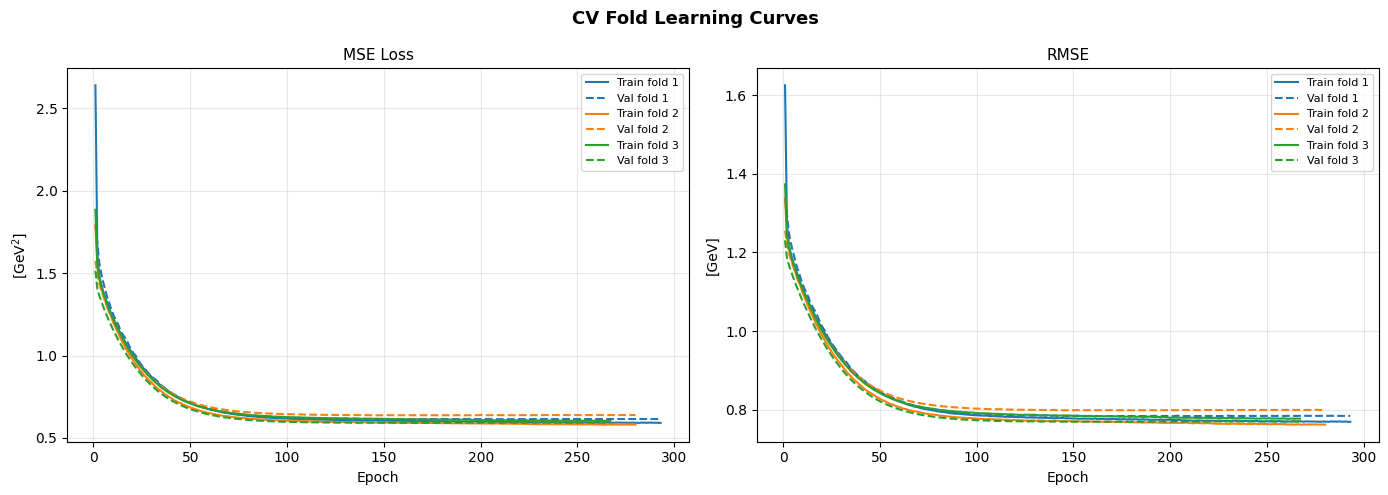

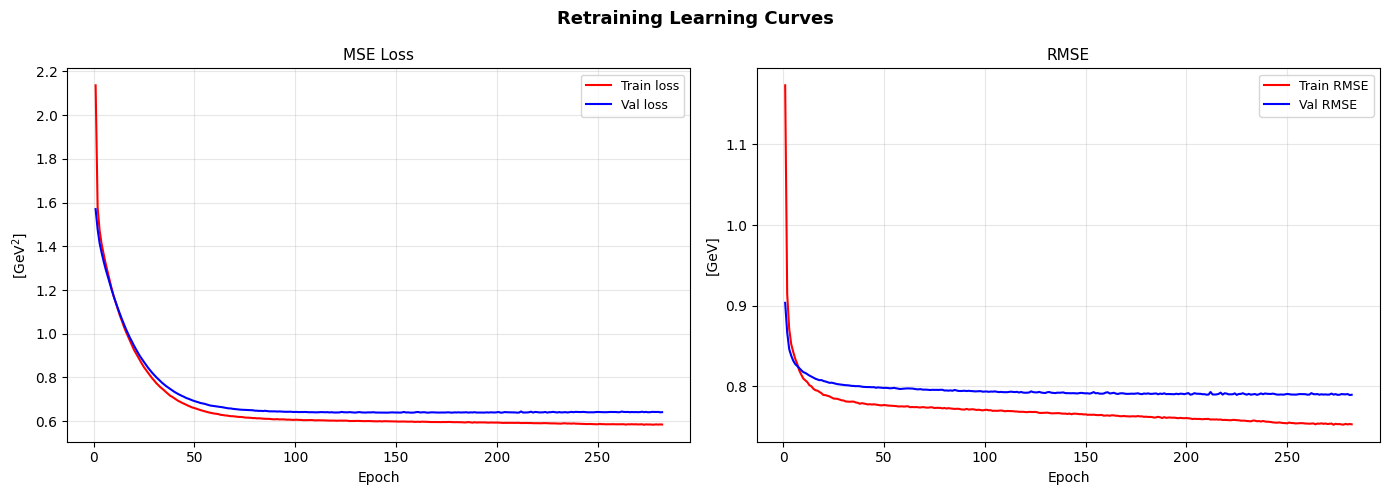

Retraining learning curves:
    Epochs run       : 282
    Final train loss : 0.5846
    Final val loss   : 0.6412
    Best val loss    : 0.6386  (epoch 202)


In [15]:

FOLD_LC_FILE = f"fold_histories_pxpy.parquet"
LC_FILE    = f"learning_curves_pxpy.parquet"

# Load fold learning curves (loss, val_loss, mse, val_mse)
df_folds = pd.read_parquet(FOLD_LC_FILE)

# Load learning curves (loss, val_loss, mse, val_mse)
df_lc = pd.read_parquet(LC_FILE)

# Fold learning curves
_plot_fold_learning_curves(df_folds)

# Learning curves
_plot_learning_curves(df_lc)

---

## DYJetsToLL

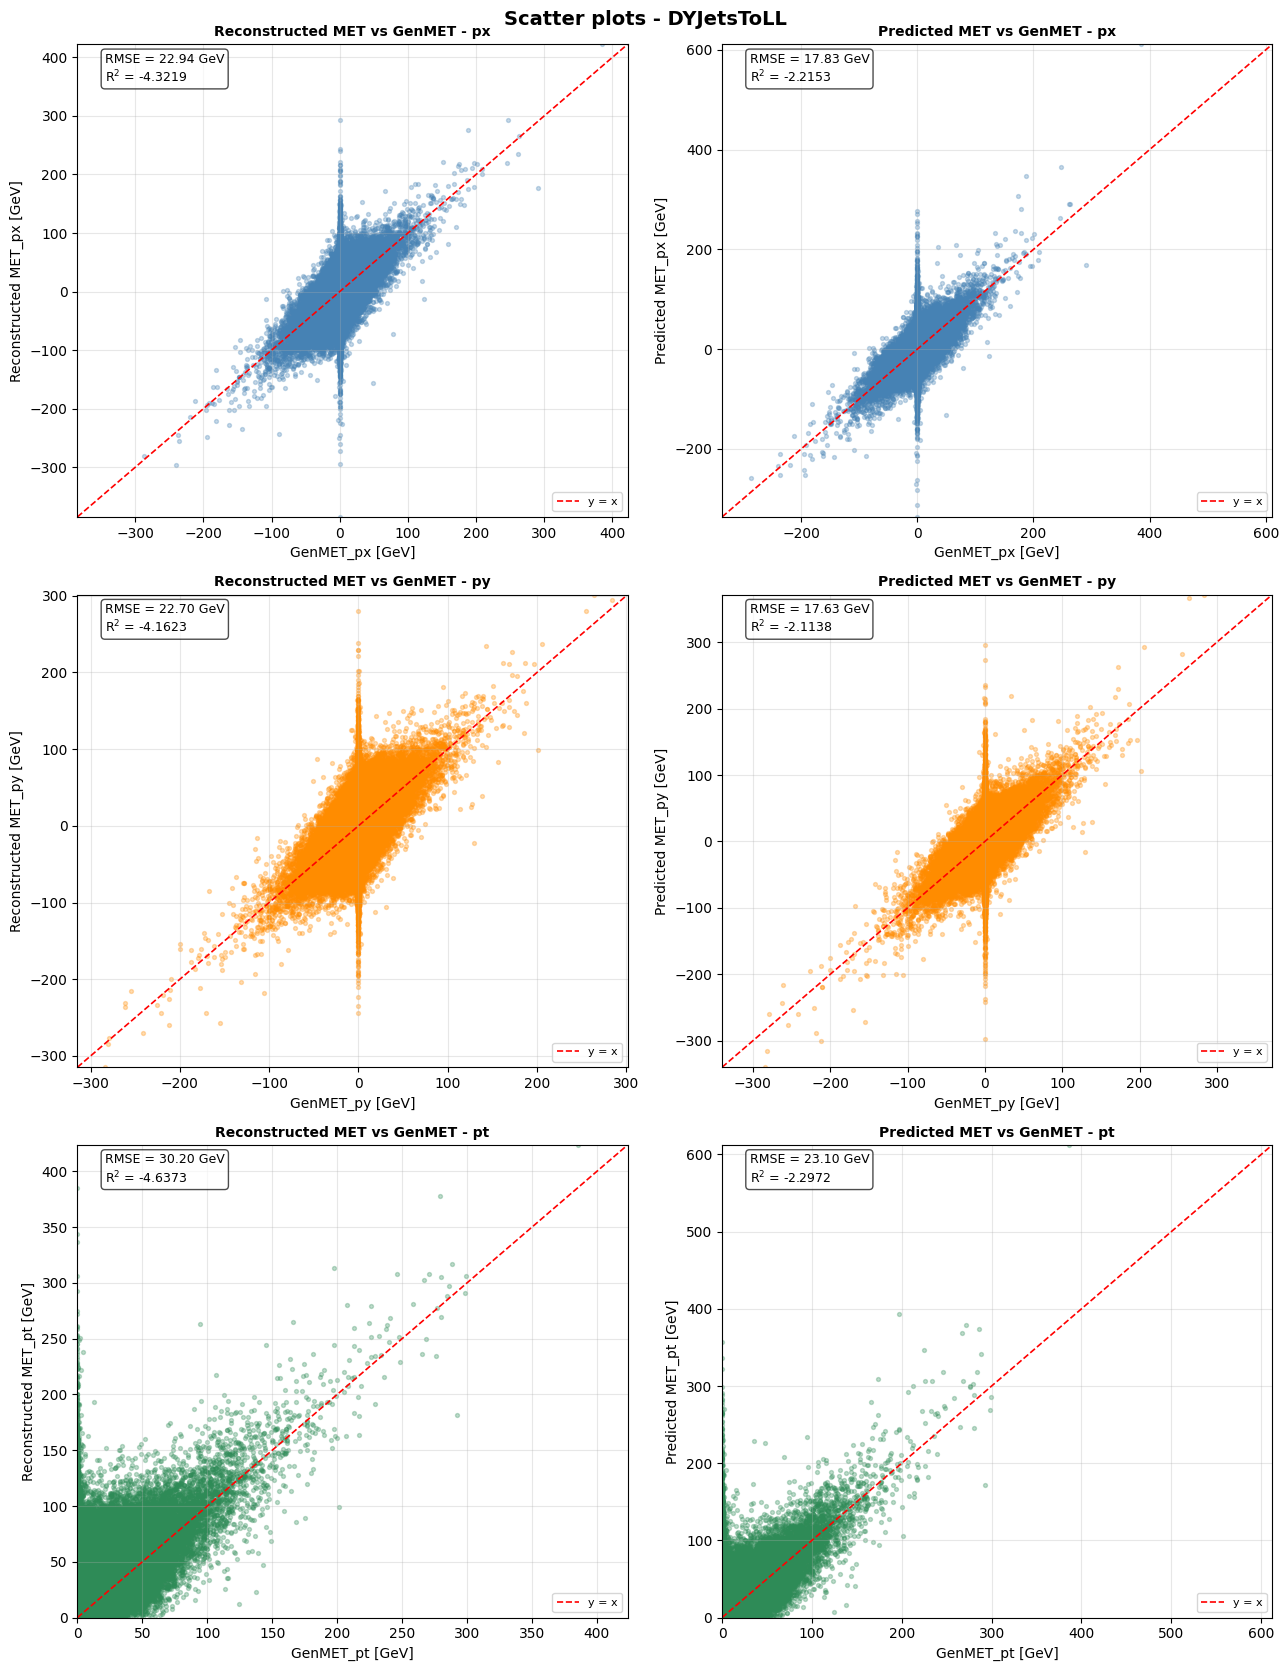


PX - DYJetsToLL
Reconstruction performance for DYJetsToLL:
    RMSE = 22.9413 GeV
    MAE  = 17.5775 GeV
    R²   = -4.3219
    Std(residuals) = 22.7127 GeV
ML model performance for DYJetsToLL:
    RMSE = 17.8319 GeV
    MAE  = 13.4521 GeV
    R²   = -2.2153
    Std(residuals) = 17.7093 GeV
Performance improvement for DYJetsToLL:
    DELTA_RMSE = +5.1095 GeV (+22.27%)
    DELTA_MAE  = +4.1254 GeV (+23.47%)
    DELTA_R²   = +2.1066     (+48.74%)
    DELTA_STD  = 5.0034    +22.03%

PY - DYJetsToLL
Reconstruction performance for DYJetsToLL:
    RMSE = 22.6979 GeV
    MAE  = 17.3825 GeV
    R²   = -4.1623
    Std(residuals) = 22.6951 GeV
ML model performance for DYJetsToLL:
    RMSE = 17.6283 GeV
    MAE  = 13.2747 GeV
    R²   = -2.1138
    Std(residuals) = 17.6273 GeV
Performance improvement for DYJetsToLL:
    DELTA_RMSE = +5.0697 GeV (+22.34%)
    DELTA_MAE  = +4.1078 GeV (+23.63%)
    DELTA_R²   = +2.0485     (+49.22%)
    DELTA_STD  = 5.0678    +22.33%

PT - DYJetsToLL
Reconstructio

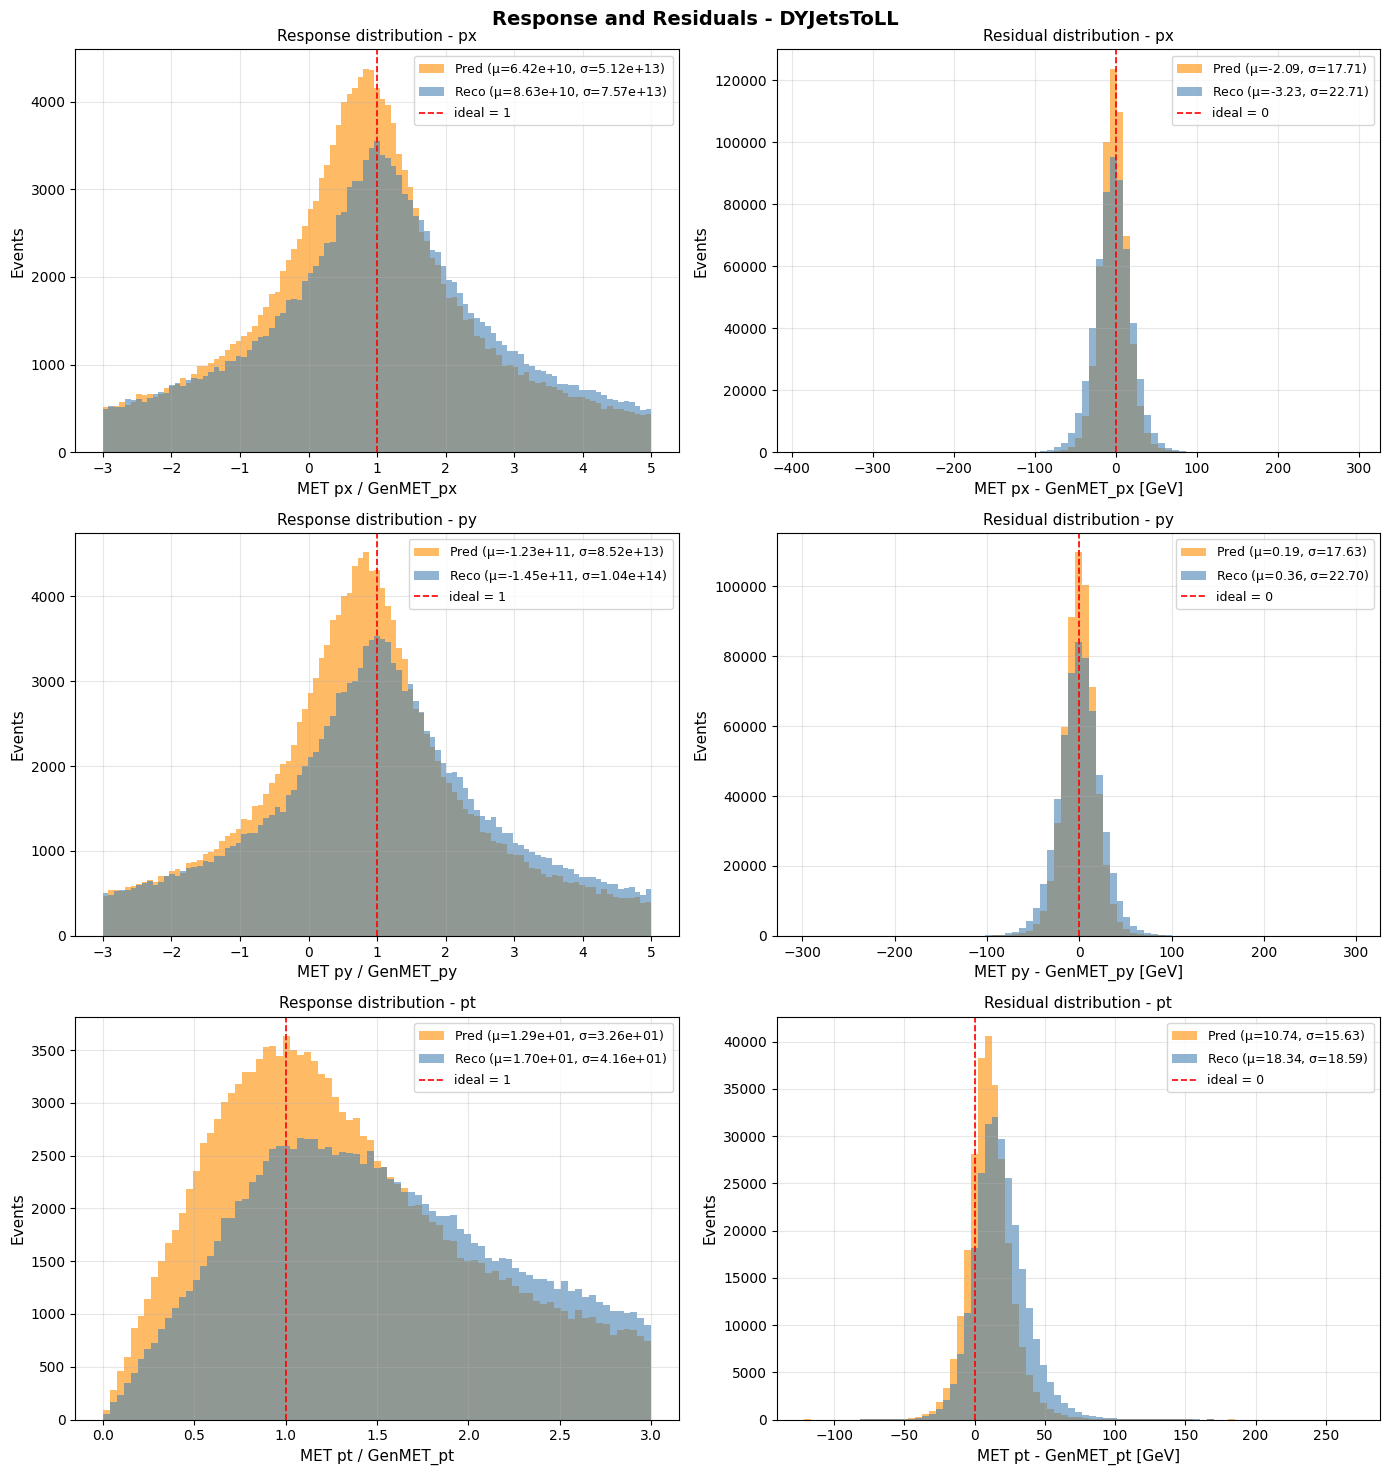

Residual Profile Histogram specifics:
    [px] bin_width=10.0 GeV | range [-160, 140] GeV | n_bins=68
    [py] bin_width=10.0 GeV | range [-140, 140] GeV | n_bins=58
  Excluding GenMET_pt <= 0.0 GeV: 0 events removed
    [pt] bin_width=10.0 GeV | range [0, 220] GeV | n_bins=39


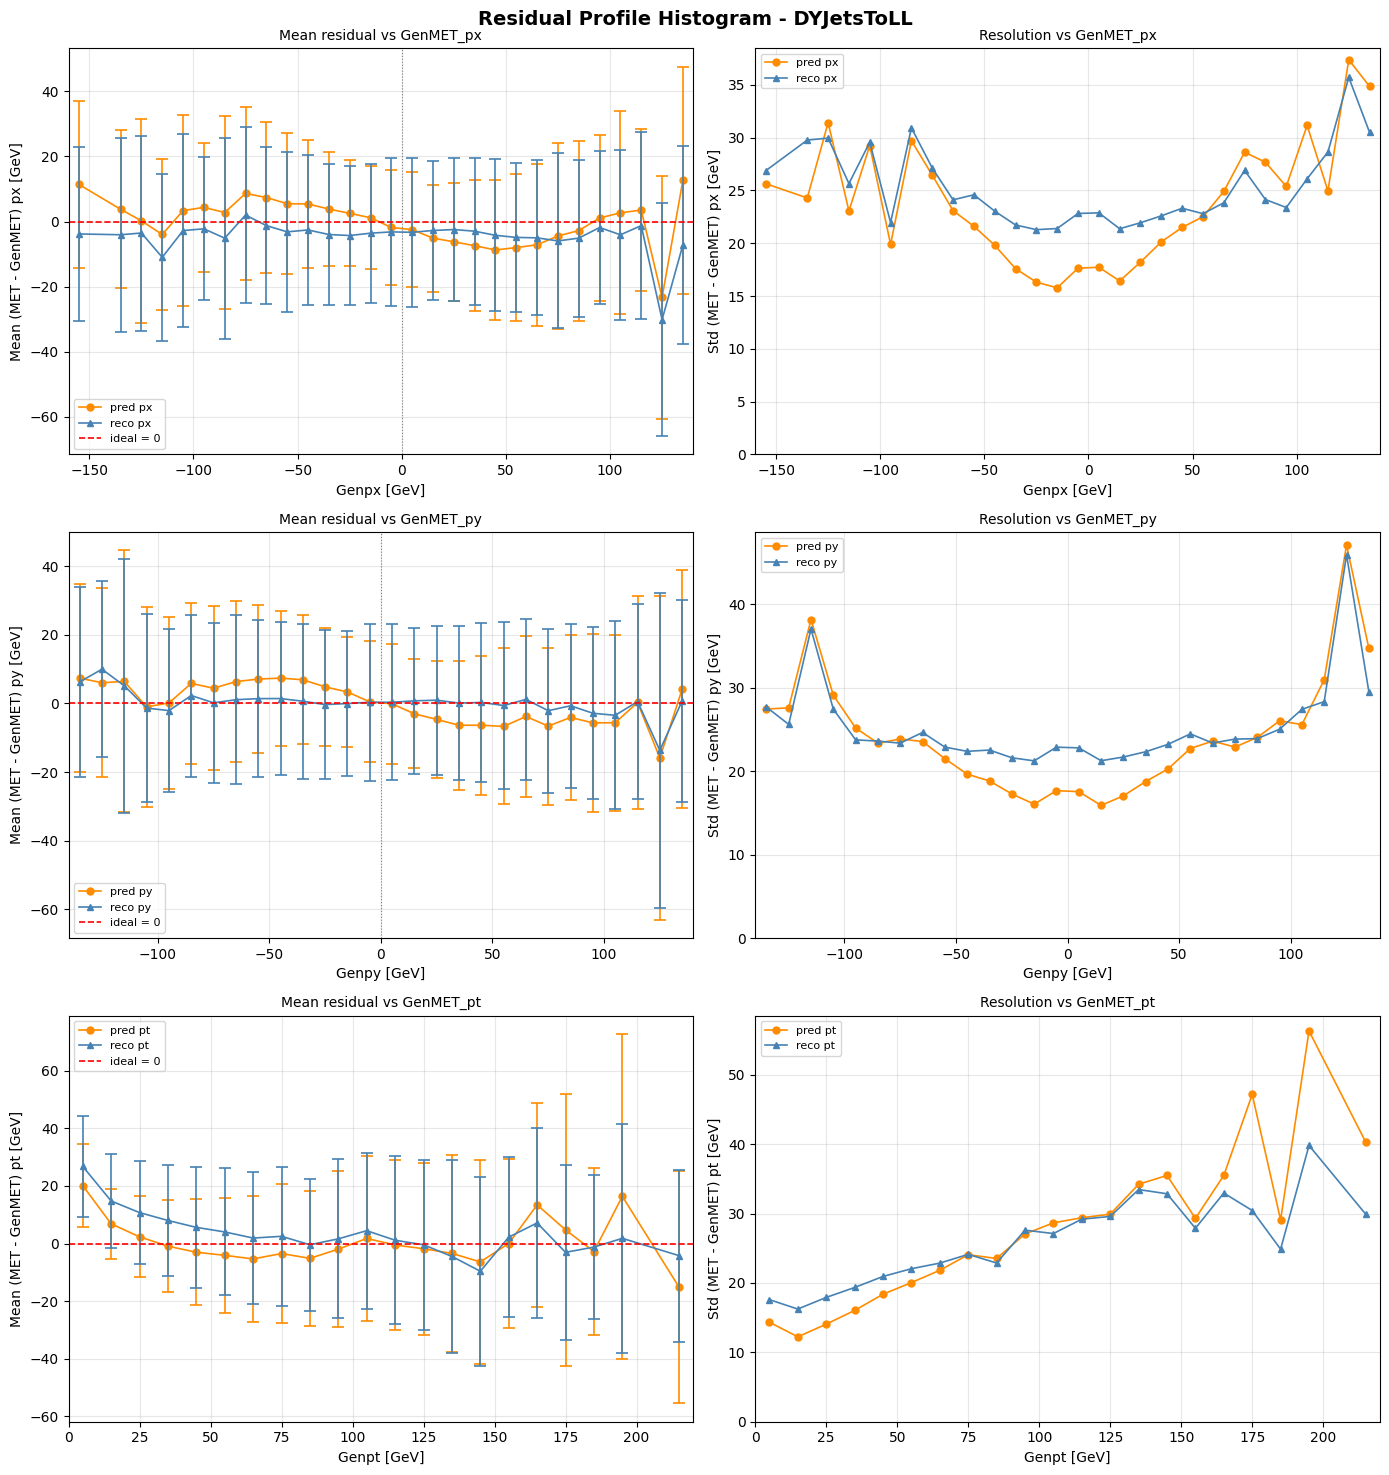

Response Profile Histogram specifics:
  Excluding |GenMET_px| <= 10.0 GeV: 497,073 events removed
    [px] bin_width=10.0 GeV | range [-160, 140] GeV | n_bins=68
  Excluding |GenMET_py| <= 10.0 GeV: 496,971 events removed
    [py] bin_width=10.0 GeV | range [-140, 140] GeV | n_bins=58
  Excluding |GenMET_pt| <= 50.0 GeV: 563,912 events removed
    [pt] bin_width=10.0 GeV | range [50, 220] GeV | n_bins=34


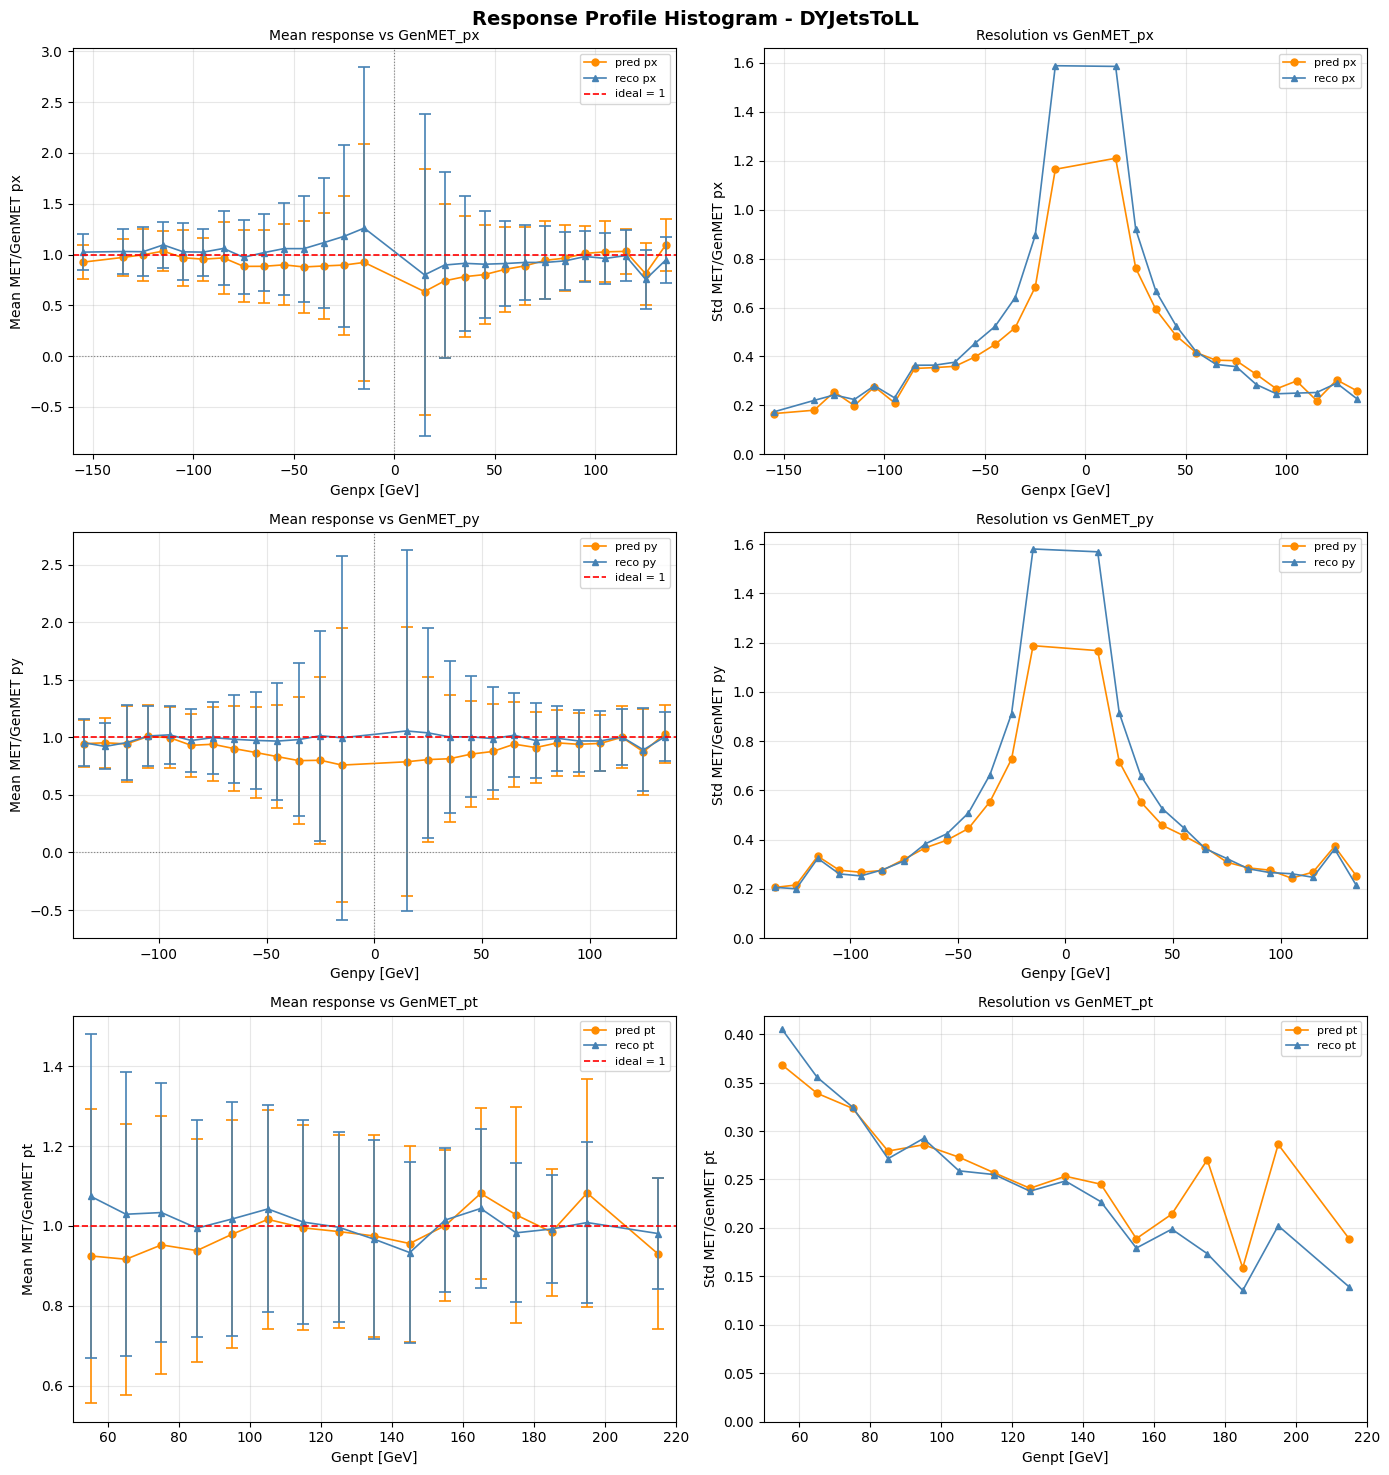

  Excluding GenMET_pt < 0.0 GeV: 0 events removed.
  Plotting up to 220 GeV.
  Last bin with >= 10 events: [210, 220] GeV, n=10


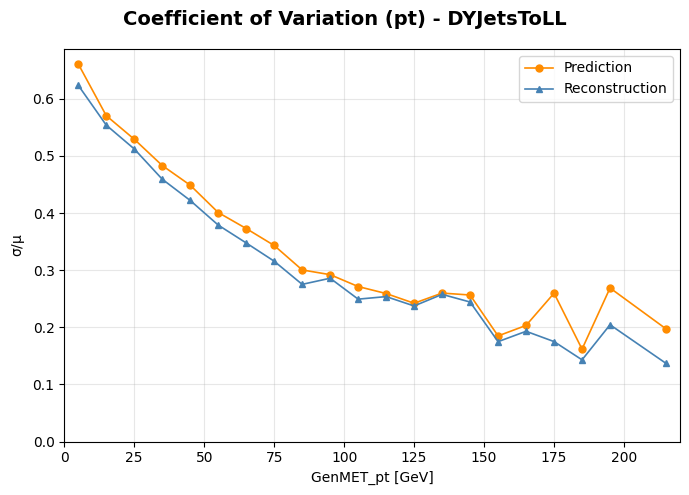

Coefficient of Variation comparison (pt):
    Bins compared: 21 / 39
    Average improvement weighted by events count: -0.0335
    Fraction of bins where prediction improves CoV: 0.0%
    Best bin: [130, 140] GeV -> Δ=-0.0022 (-0.9%)
    Worst bin: [170, 180] GeV -> Δ=-0.0847 (-48.4%)


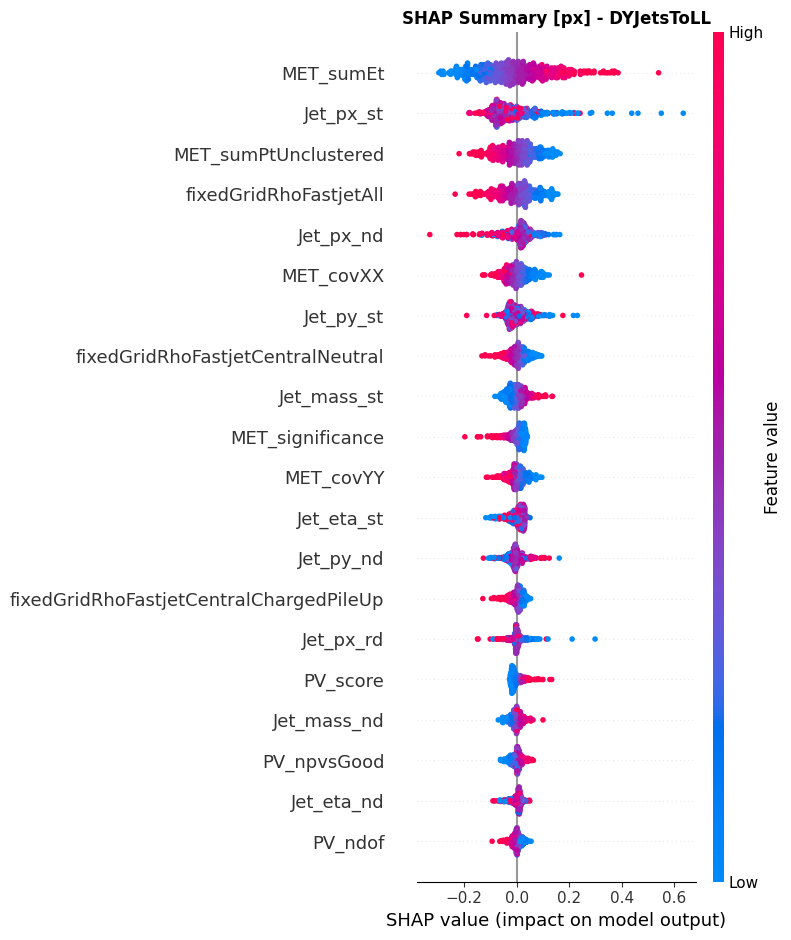


  Feature importance (mean |SHAP|) [px] for DYJetsToLL:
    MET_sumEt                           0.1101
    Jet_px_st                           0.0672
    MET_sumPtUnclustered                0.0563
    fixedGridRhoFastjetAll              0.0550
    Jet_px_nd                           0.0421
    MET_covXX                           0.0356
    Jet_py_st                           0.0305
    fixedGridRhoFastjetCentralNeutral   0.0269
    Jet_mass_st                         0.0253
    MET_significance                    0.0231
    MET_covYY                           0.0230
    Jet_eta_st                          0.0219
    Jet_py_nd                           0.0211
    fixedGridRhoFastjetCentralChargedPileUp 0.0184
    Jet_px_rd                           0.0174
    PV_score                            0.0172
    Jet_mass_nd                         0.0164
    PV_npvsGood                         0.0154
    Jet_eta_nd                          0.0149
    PV_ndof                             0.0137

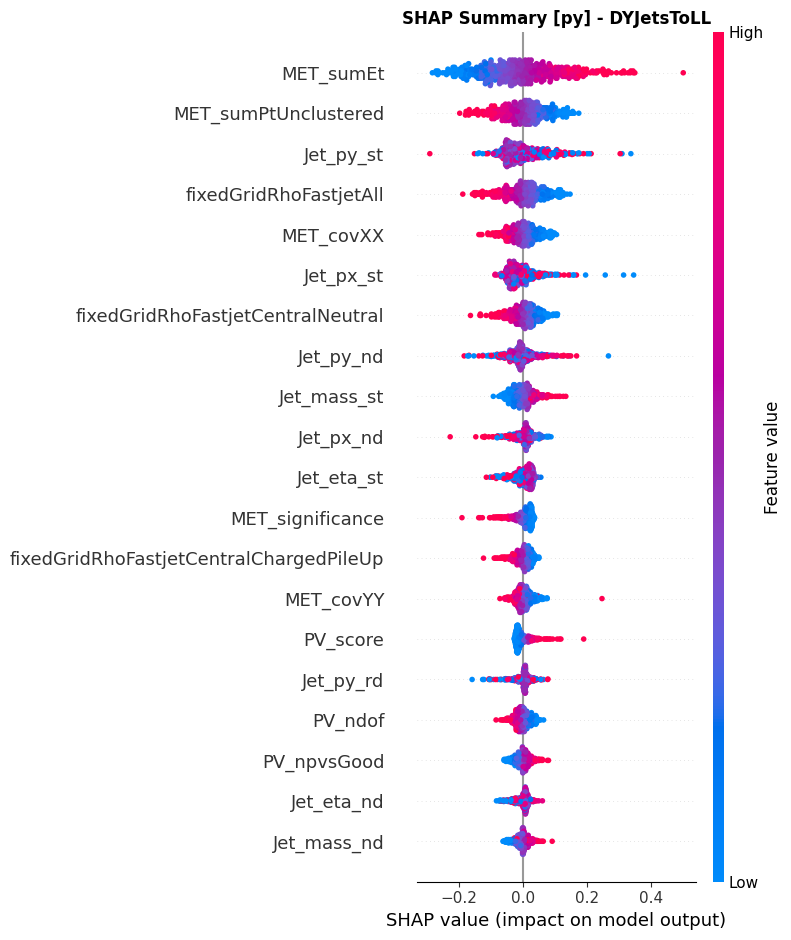


  Feature importance (mean |SHAP|) [py] for DYJetsToLL:
    MET_sumEt                           0.1022
    MET_sumPtUnclustered                0.0560
    Jet_py_st                           0.0495
    fixedGridRhoFastjetAll              0.0484
    MET_covXX                           0.0338
    Jet_px_st                           0.0328
    fixedGridRhoFastjetCentralNeutral   0.0324
    Jet_py_nd                           0.0321
    Jet_mass_st                         0.0259
    Jet_px_nd                           0.0234
    Jet_eta_st                          0.0226
    MET_significance                    0.0212
    fixedGridRhoFastjetCentralChargedPileUp 0.0190
    MET_covYY                           0.0180
    PV_score                            0.0175
    Jet_py_rd                           0.0170
    PV_ndof                             0.0170
    PV_npvsGood                         0.0167
    Jet_eta_nd                          0.0153
    Jet_mass_nd                         0.0151

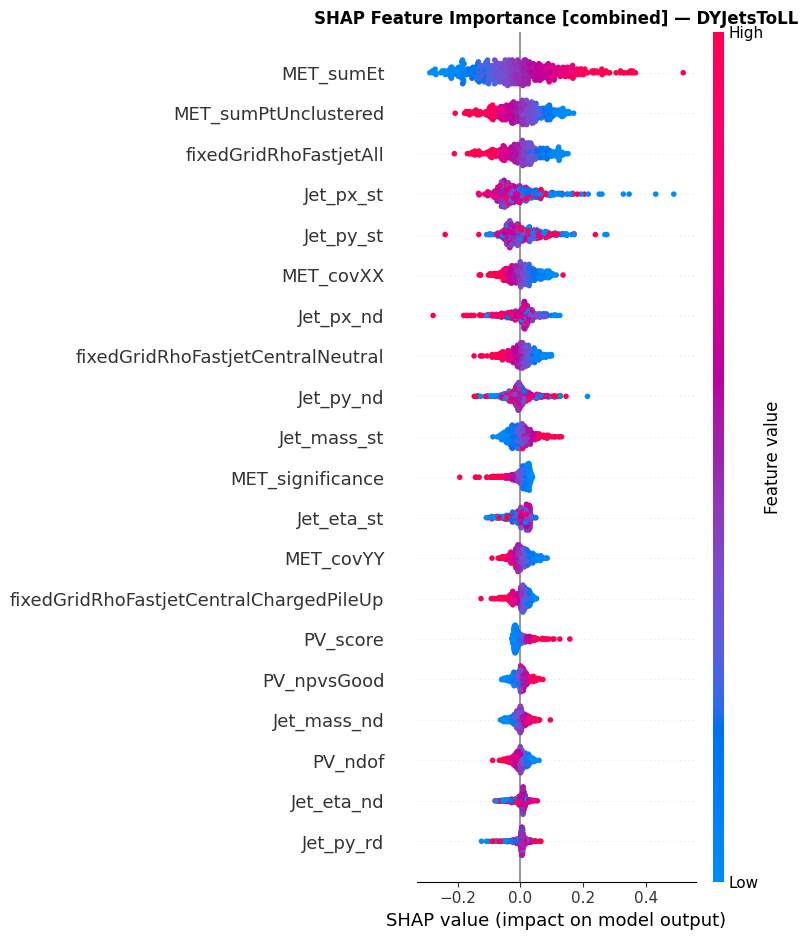


  Feature importance (mean |SHAP|) [combined] for DYJetsToLL:
    MET_sumEt                           0.1061
    MET_sumPtUnclustered                0.0561
    fixedGridRhoFastjetAll              0.0517
    Jet_px_st                           0.0497
    Jet_py_st                           0.0398
    MET_covXX                           0.0347
    Jet_px_nd                           0.0327
    fixedGridRhoFastjetCentralNeutral   0.0296
    Jet_py_nd                           0.0265
    Jet_mass_st                         0.0256
    MET_significance                    0.0222
    Jet_eta_st                          0.0218
    MET_covYY                           0.0202
    fixedGridRhoFastjetCentralChargedPileUp 0.0187
    PV_score                            0.0173
    PV_npvsGood                         0.0160
    Jet_mass_nd                         0.0157
    PV_ndof                             0.0152
    Jet_eta_nd                          0.0147
    Jet_py_rd                           

In [16]:
EVENT      = "DYJetsToLL"
PRED_FILE = f"predictions_testing_pxpy_{EVENT}.parquet"
MODEL_DIR = "."

# Reconstructed/Predicted MET vs GenMET
(pred_px, pred_py, pred_pt,
    true_px, true_py, true_pt,
    reco_px, reco_py, reco_pt) = load_predictions(EVENT)

# Scatterplots
_scatterplots(
            pred_px, pred_py, pred_pt,
            true_px, true_py, true_pt,
            reco_px, reco_py, reco_pt,
            event=EVENT,
        )

# Performance metrics
_compute_metrics(
            pred_px, pred_py, pred_pt,
            true_px, true_py, true_pt,
            reco_px, reco_py, reco_pt,
            event=EVENT,
        )

# Response and residual histograms
_response_and_residual_plots(
            pred_px, pred_py, pred_pt,
            true_px, true_py, true_pt,
            reco_px, reco_py, reco_pt,
            event=EVENT
        )

# Profile histogram residuals
_profile_histogram_residuals(
            pred_px, pred_py, pred_pt,
            true_px, true_py, true_pt,
            reco_px, reco_py, reco_pt,
            event=EVENT, bin_width = 10.0,
            min_counts = 10, min_Gen = 0.0
        )

# Profile histogram response
_profile_histogram_response(
            pred_px, pred_py, pred_pt,
            true_px, true_py, true_pt,
            reco_px, reco_py, reco_pt,
            event=EVENT, bin_width= 10.0,
            min_counts = 10, min_Gen = 50.0,
            min_Gen_pxpy = 10.0
        )

# Profile histogram CoV
_profile_coefficient_of_variation(
            pred_pt, true_pt, reco_pt,
            event=EVENT, bin_width = 10.0,
            min_counts = 10, min_Gen = 0.0
        )

# SHAP
model, scaler, run_summary = load_model_and_scaler(MODEL_DIR)
_feature_importance_shap(model, EVENT)

---

## HToAATo2Mu2B

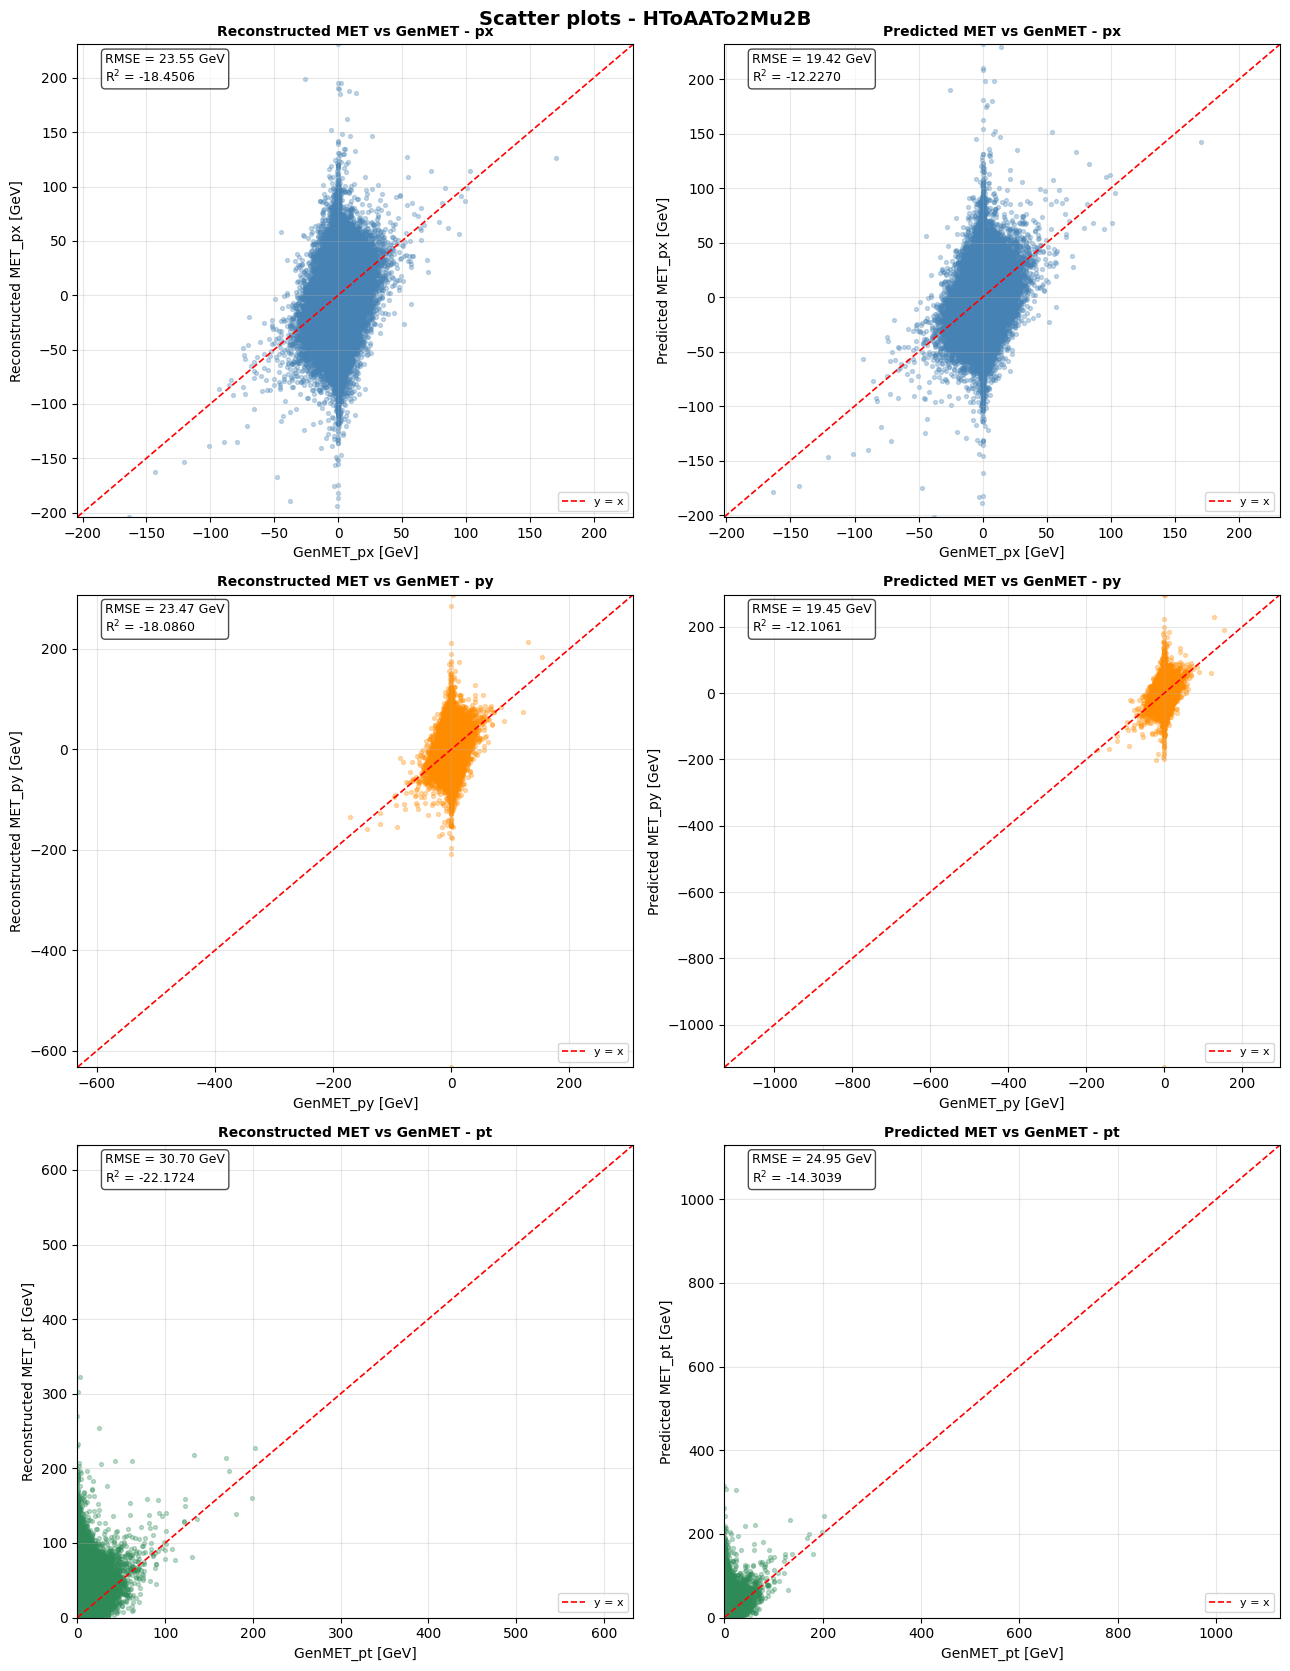


PX - HToAATo2Mu2B
Reconstruction performance for HToAATo2Mu2B:
    RMSE = 23.5523 GeV
    MAE  = 17.9620 GeV
    R²   = -18.4506
    Std(residuals) = 23.3455 GeV
ML model performance for HToAATo2Mu2B:
    RMSE = 19.4222 GeV
    MAE  = 14.8339 GeV
    R²   = -12.2270
    Std(residuals) = 19.2928 GeV
Performance improvement for HToAATo2Mu2B:
    DELTA_RMSE = +4.1301 GeV (+17.54%)
    DELTA_MAE  = +3.1281 GeV (+17.42%)
    DELTA_R²   = +6.2235     (+33.73%)
    DELTA_STD  = 4.0526    +17.36%

PY - HToAATo2Mu2B
Reconstruction performance for HToAATo2Mu2B:
    RMSE = 23.4709 GeV
    MAE  = 17.8761 GeV
    R²   = -18.0860
    Std(residuals) = 23.4668 GeV
ML model performance for HToAATo2Mu2B:
    RMSE = 19.4495 GeV
    MAE  = 14.6885 GeV
    R²   = -12.1061
    Std(residuals) = 19.4479 GeV
Performance improvement for HToAATo2Mu2B:
    DELTA_RMSE = +4.0214 GeV (+17.13%)
    DELTA_MAE  = +3.1876 GeV (+17.83%)
    DELTA_R²   = +5.9799     (+33.06%)
    DELTA_STD  = 4.0189    +17.13%

PT - HToA

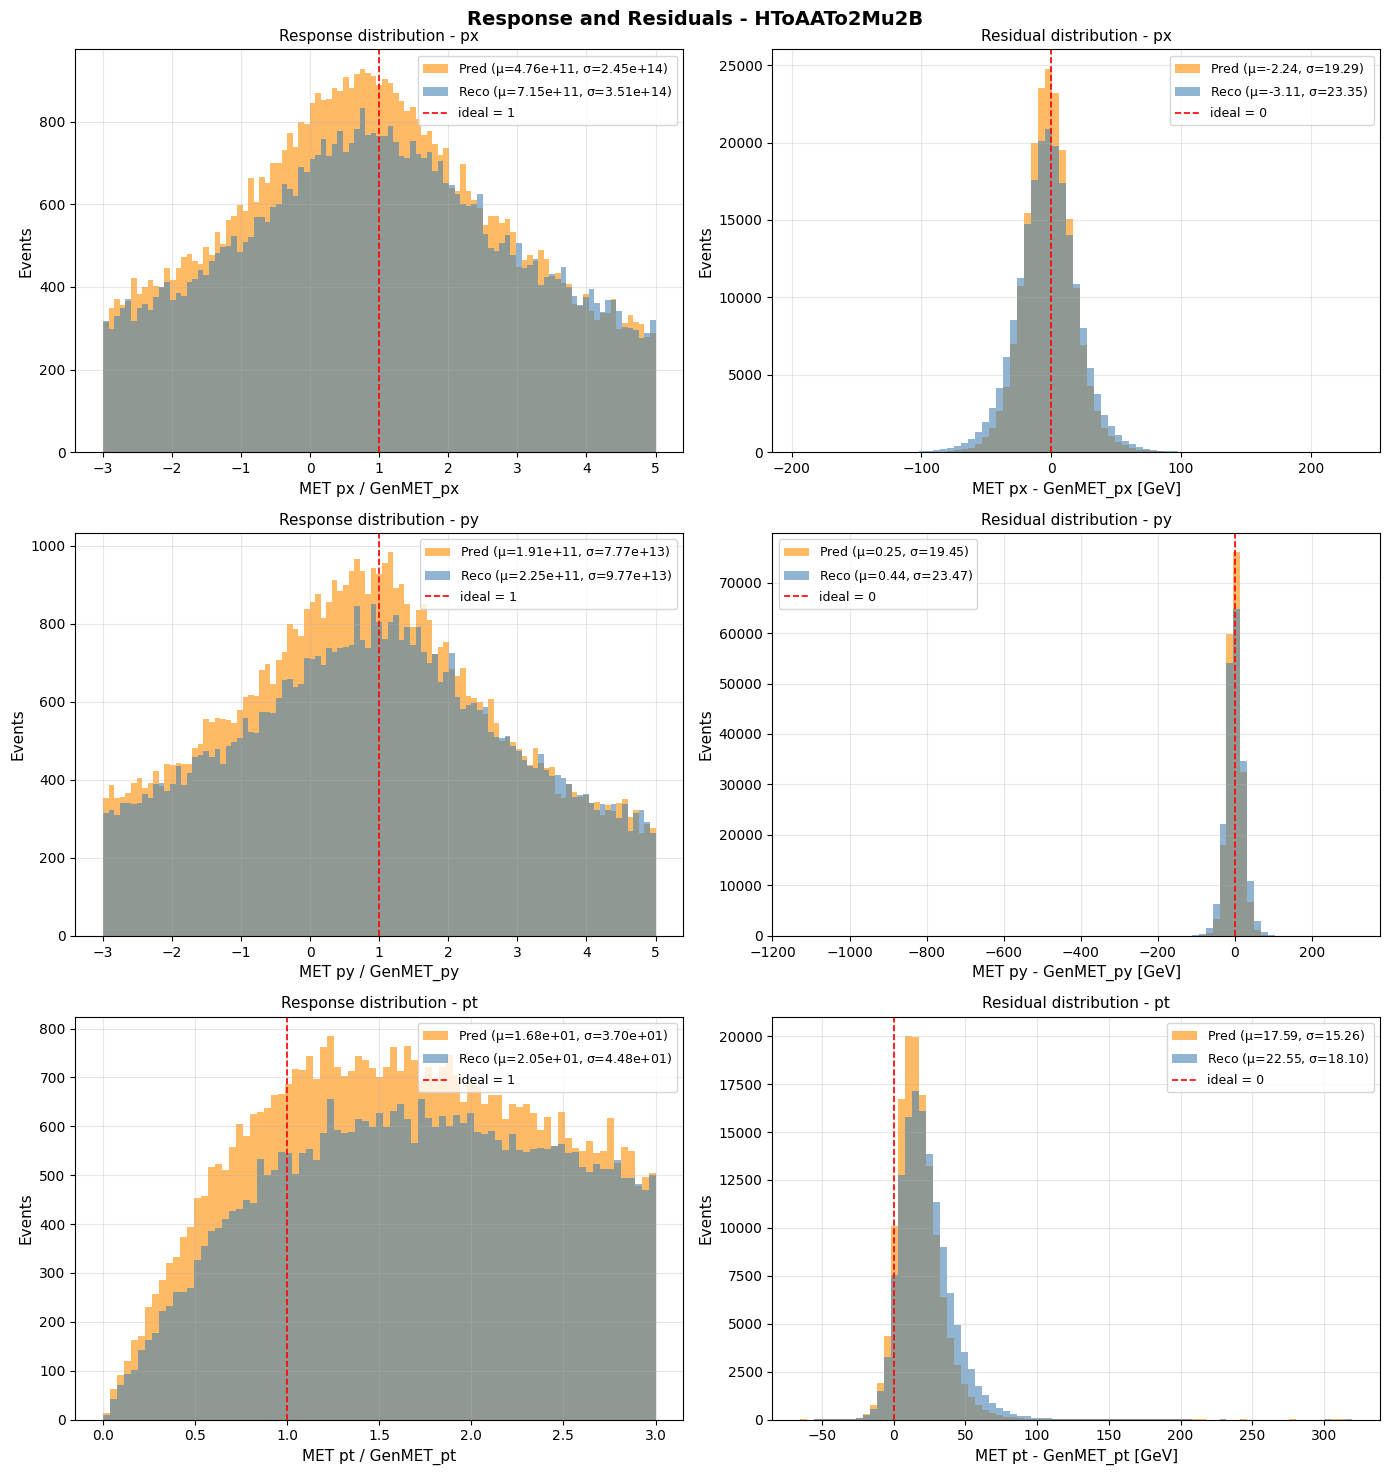

Residual Profile Histogram specifics:
    [px] bin_width=10.0 GeV | range [-70, 60] GeV | n_bins=35
    [py] bin_width=10.0 GeV | range [-60, 70] GeV | n_bins=34
  Excluding GenMET_pt <= 10.0 GeV: 172,520 events removed
    [pt] bin_width=10.0 GeV | range [10, 90] GeV | n_bins=20


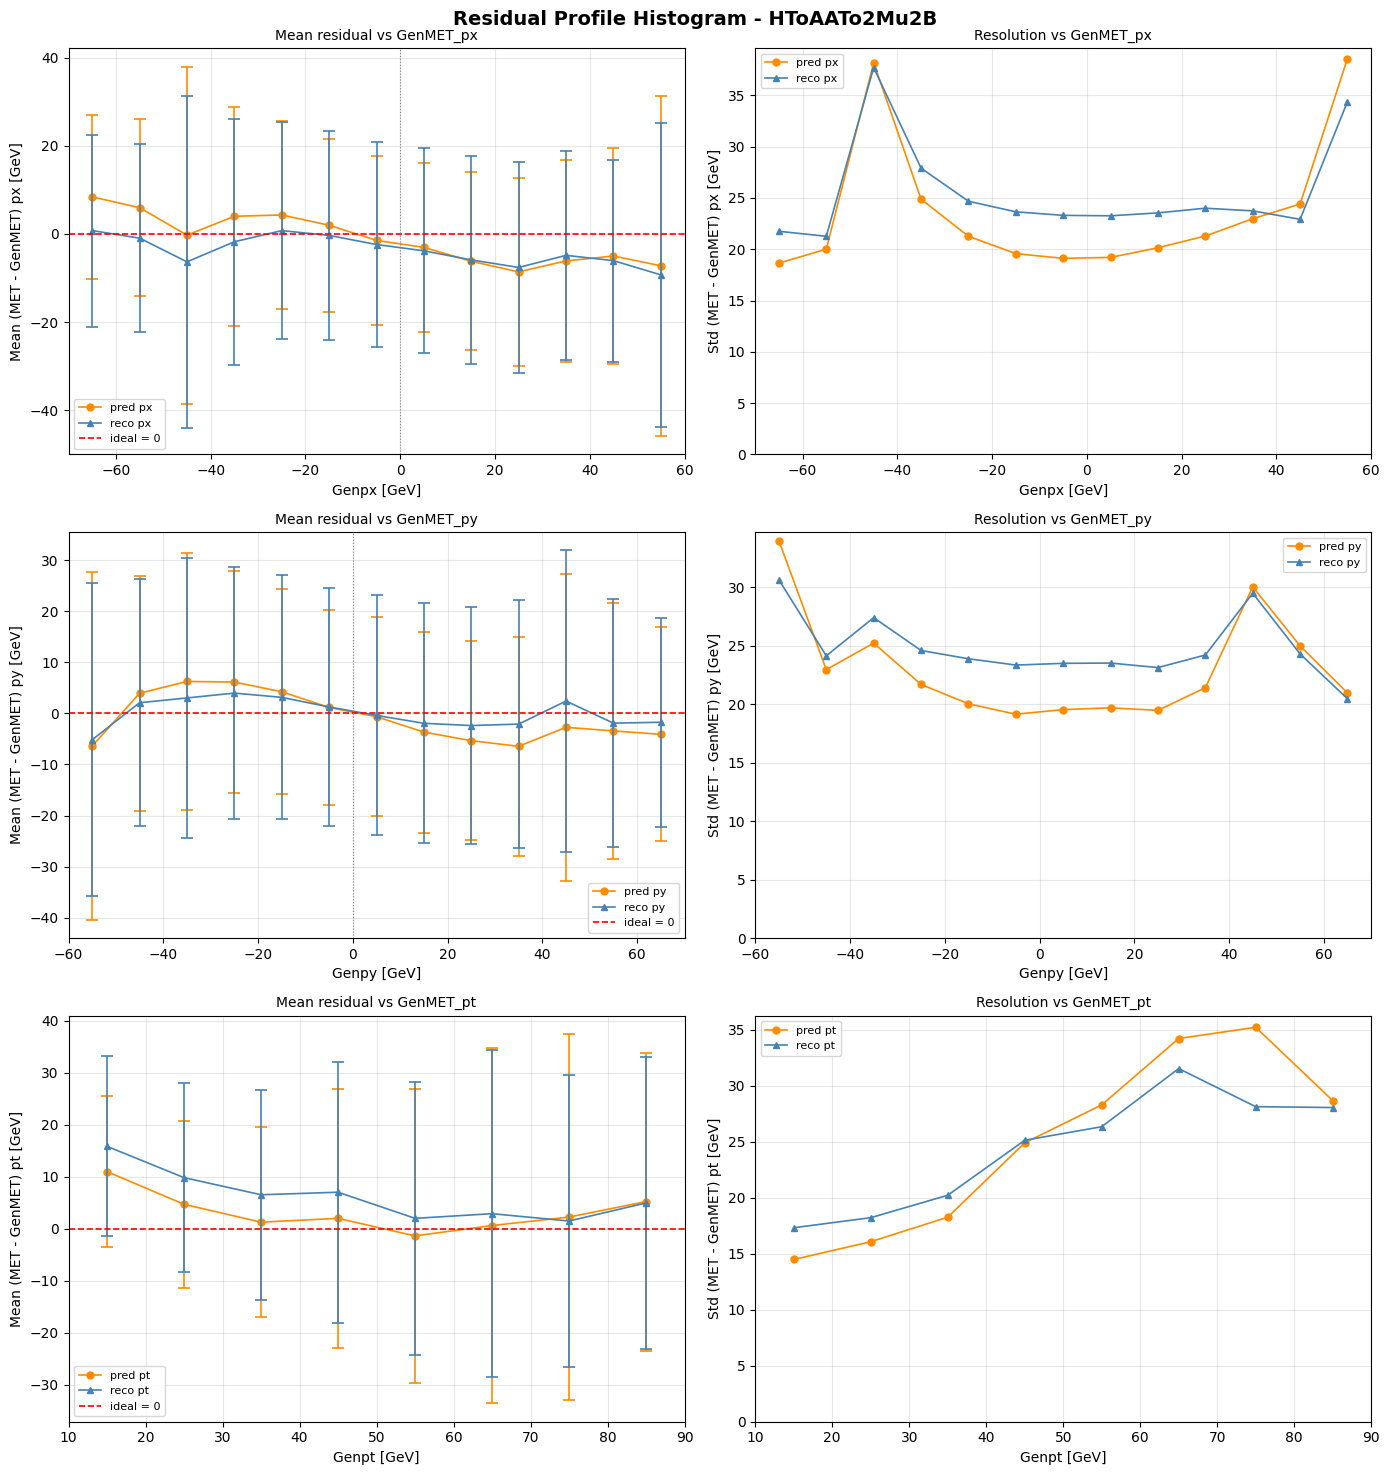

Response Profile Histogram specifics:
  Excluding |GenMET_px| <= 10.0 GeV: 185,696 events removed
    [px] bin_width=10.0 GeV | range [-70, 60] GeV | n_bins=35
  Excluding |GenMET_py| <= 10.0 GeV: 185,401 events removed
    [py] bin_width=10.0 GeV | range [-60, 70] GeV | n_bins=34
  Excluding |GenMET_pt| <= 10.0 GeV: 172,520 events removed
    [pt] bin_width=10.0 GeV | range [10, 90] GeV | n_bins=20


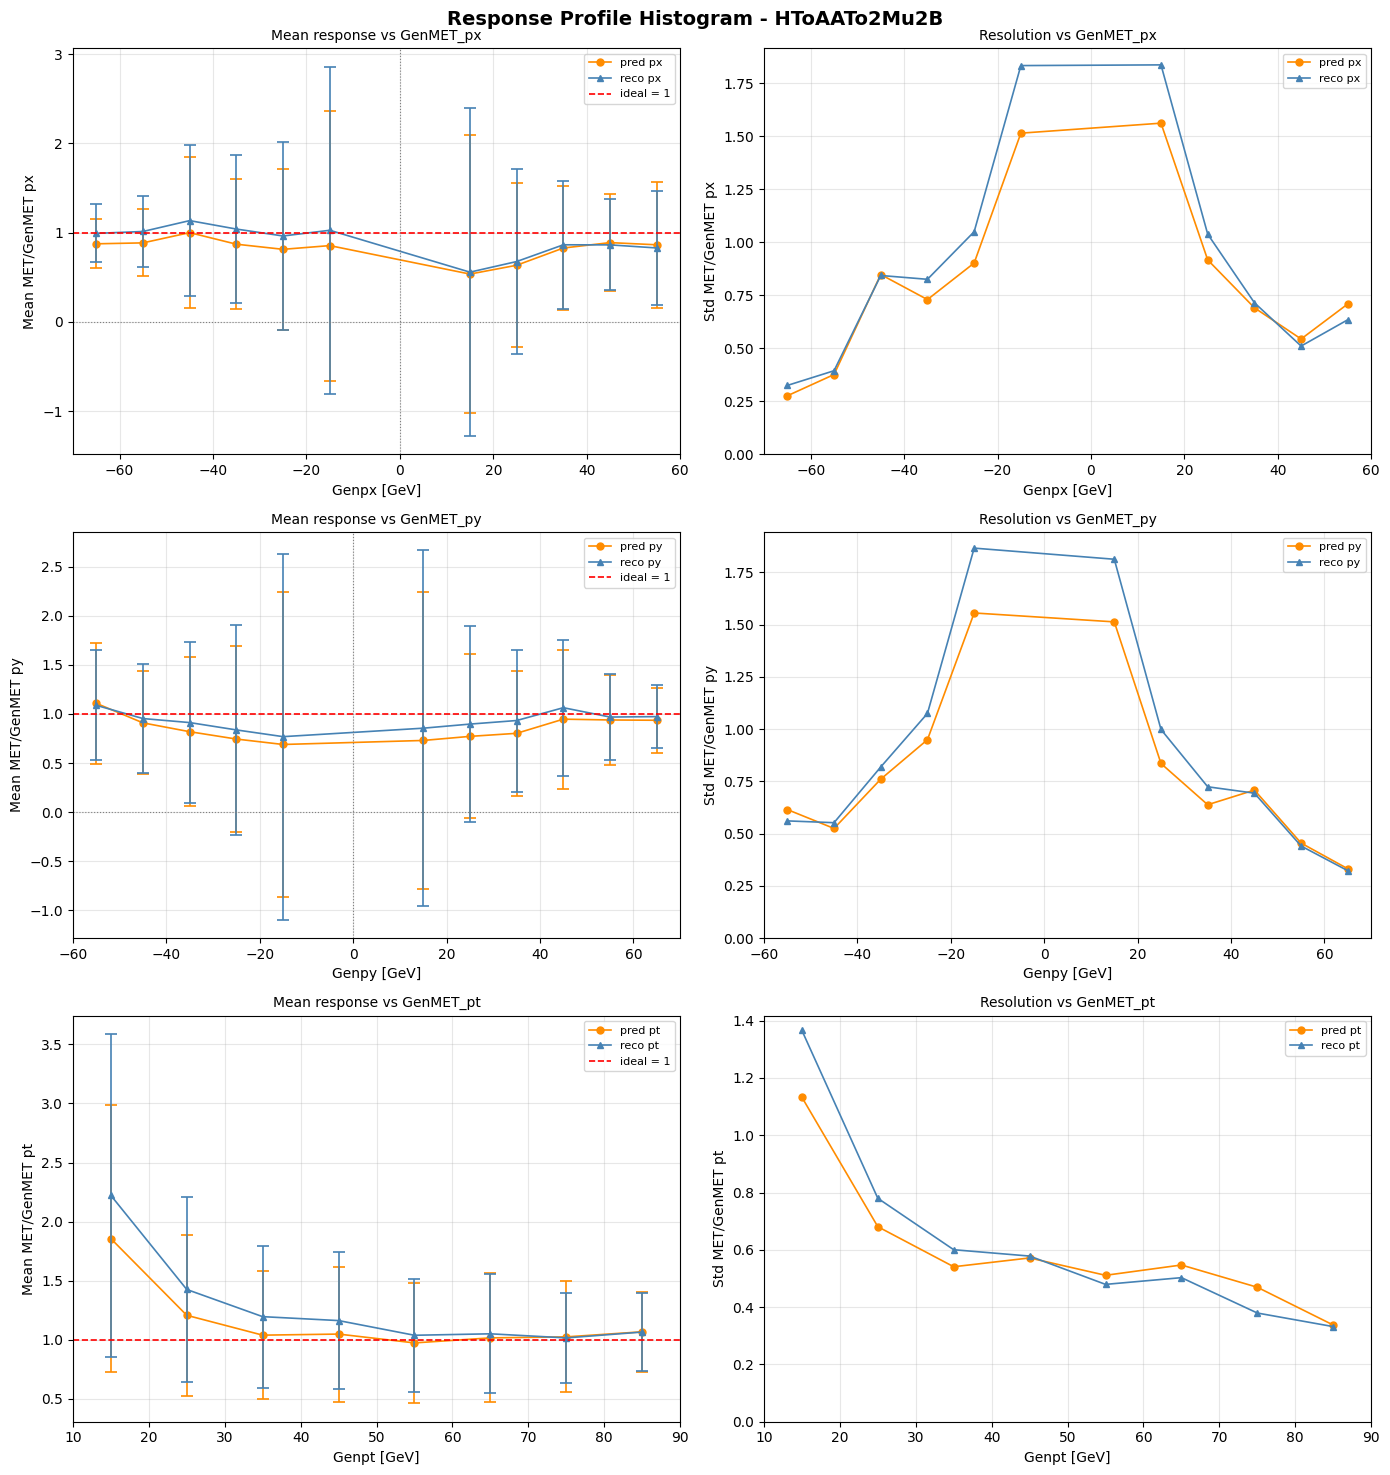

  Excluding GenMET_pt < 0.0 GeV: 0 events removed.
  Plotting up to 90 GeV.
  Last bin with >= 10 events: [80, 90] GeV, n=16


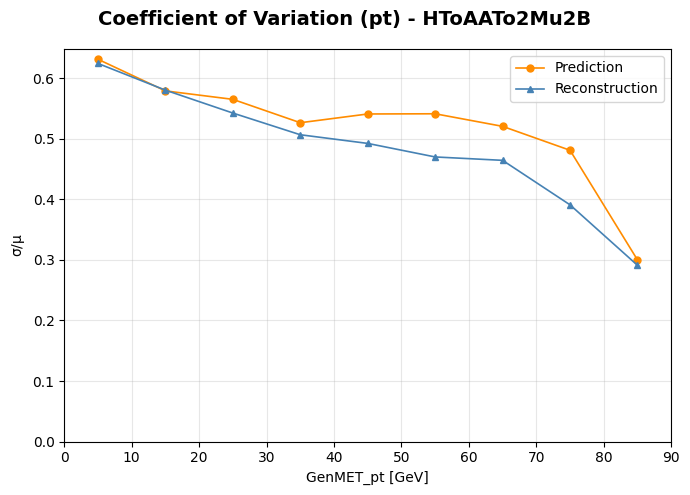

Coefficient of Variation comparison (pt):
    Bins compared: 9 / 21
    Average improvement weighted by events count: -0.0066
    Fraction of bins where prediction improves CoV: 11.1%
    Best bin: [10, 20] GeV -> Δ=+0.0012 (+0.2%)
    Worst bin: [70, 80] GeV -> Δ=-0.0901 (-23.1%)


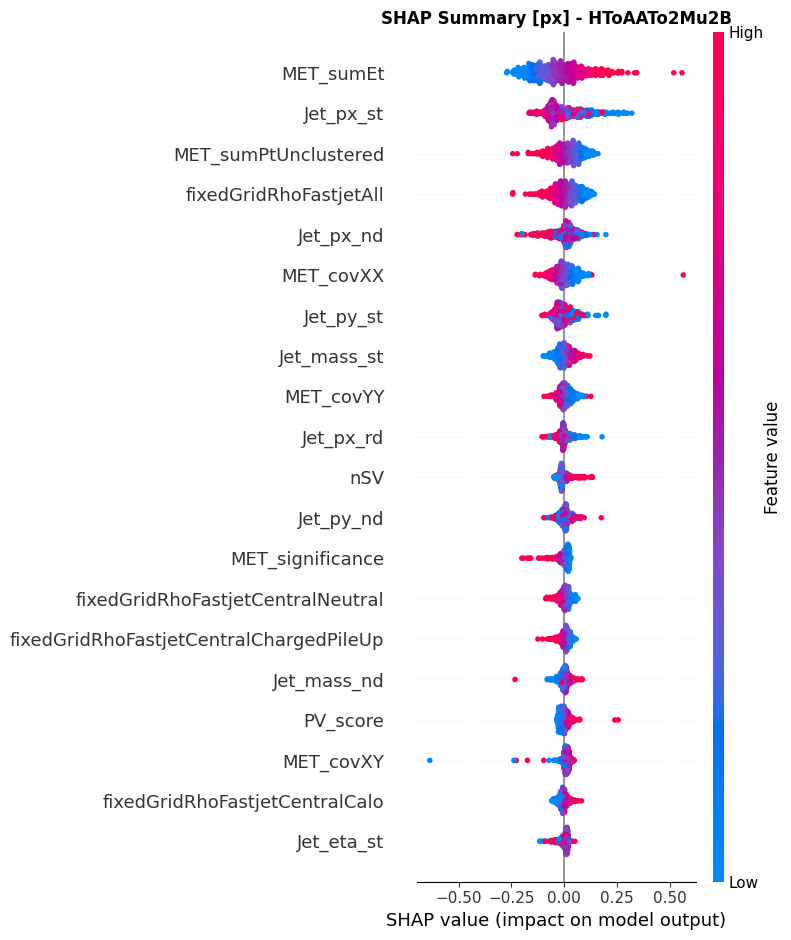


  Feature importance (mean |SHAP|) [px] for HToAATo2Mu2B:
    MET_sumEt                           0.0989
    Jet_px_st                           0.0692
    MET_sumPtUnclustered                0.0508
    fixedGridRhoFastjetAll              0.0495
    Jet_px_nd                           0.0418
    MET_covXX                           0.0373
    Jet_py_st                           0.0316
    Jet_mass_st                         0.0295
    MET_covYY                           0.0220
    Jet_px_rd                           0.0210
    nSV                                 0.0201
    Jet_py_nd                           0.0198
    MET_significance                    0.0188
    fixedGridRhoFastjetCentralNeutral   0.0183
    fixedGridRhoFastjetCentralChargedPileUp 0.0173
    Jet_mass_nd                         0.0169
    PV_score                            0.0167
    MET_covXY                           0.0162
    fixedGridRhoFastjetCentralCalo      0.0161
    Jet_eta_st                          0.01

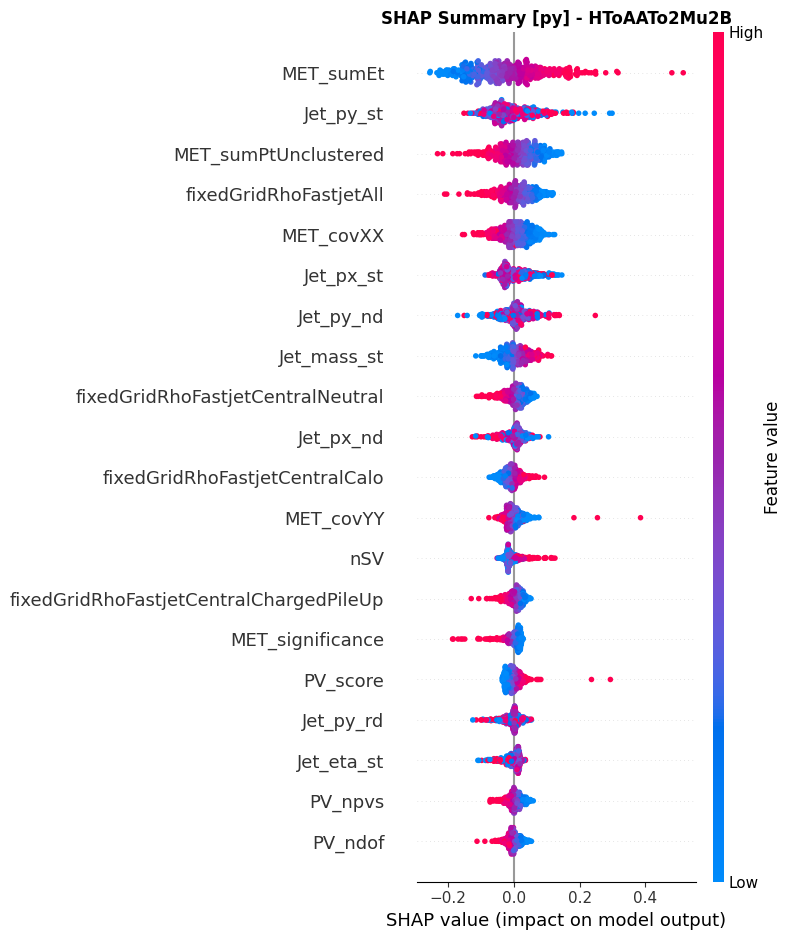


  Feature importance (mean |SHAP|) [py] for HToAATo2Mu2B:
    MET_sumEt                           0.0920
    Jet_py_st                           0.0514
    MET_sumPtUnclustered                0.0505
    fixedGridRhoFastjetAll              0.0424
    MET_covXX                           0.0368
    Jet_px_st                           0.0333
    Jet_py_nd                           0.0328
    Jet_mass_st                         0.0311
    fixedGridRhoFastjetCentralNeutral   0.0245
    Jet_px_nd                           0.0230
    fixedGridRhoFastjetCentralCalo      0.0197
    MET_covYY                           0.0190
    nSV                                 0.0189
    fixedGridRhoFastjetCentralChargedPileUp 0.0182
    MET_significance                    0.0174
    PV_score                            0.0171
    Jet_py_rd                           0.0170
    Jet_eta_st                          0.0160
    PV_npvs                             0.0157
    PV_ndof                             0.01

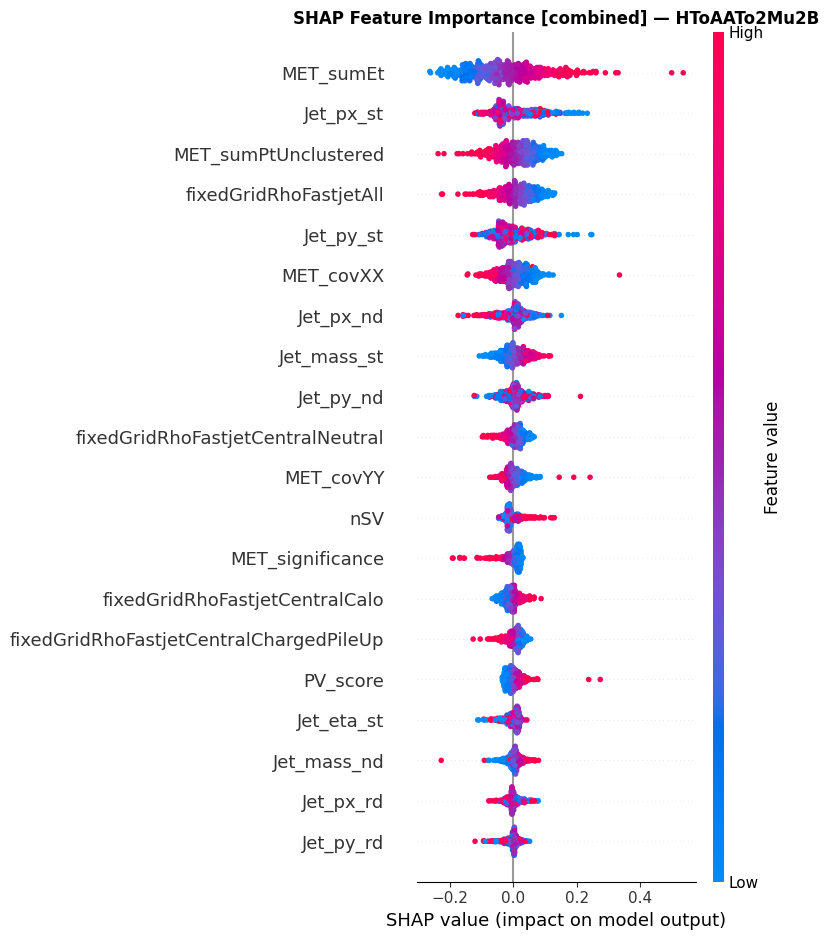


  Feature importance (mean |SHAP|) [combined] for HToAATo2Mu2B:
    MET_sumEt                           0.0954
    Jet_px_st                           0.0509
    MET_sumPtUnclustered                0.0506
    fixedGridRhoFastjetAll              0.0460
    Jet_py_st                           0.0413
    MET_covXX                           0.0367
    Jet_px_nd                           0.0323
    Jet_mass_st                         0.0302
    Jet_py_nd                           0.0261
    fixedGridRhoFastjetCentralNeutral   0.0214
    MET_covYY                           0.0204
    nSV                                 0.0193
    MET_significance                    0.0181
    fixedGridRhoFastjetCentralCalo      0.0178
    fixedGridRhoFastjetCentralChargedPileUp 0.0177
    PV_score                            0.0169
    Jet_eta_st                          0.0154
    Jet_mass_nd                         0.0152
    Jet_px_rd                           0.0147
    Jet_py_rd                         

In [17]:
EVENT      = "HToAATo2Mu2B"
PRED_FILE = f"predictions_testing_pxpy_{EVENT}.parquet"
MODEL_DIR = "."

# Reconstructed/Predicted MET vs GenMET
(pred_px, pred_py, pred_pt,
    true_px, true_py, true_pt,
    reco_px, reco_py, reco_pt) = load_predictions(EVENT)

# Scatterplots
_scatterplots(
            pred_px, pred_py, pred_pt,
            true_px, true_py, true_pt,
            reco_px, reco_py, reco_pt,
            event=EVENT,
        )

# Performance metrics
_compute_metrics(
            pred_px, pred_py, pred_pt,
            true_px, true_py, true_pt,
            reco_px, reco_py, reco_pt,
            event=EVENT,
        )

# Response and residual histograms
_response_and_residual_plots(
            pred_px, pred_py, pred_pt,
            true_px, true_py, true_pt,
            reco_px, reco_py, reco_pt,
            event=EVENT
        )

# Profile histogram residuals
_profile_histogram_residuals(
            pred_px, pred_py, pred_pt,
            true_px, true_py, true_pt,
            reco_px, reco_py, reco_pt,
            event=EVENT, bin_width = 10.0,
            min_counts = 10, min_Gen = 10.0
        )

# Profile histogram response
_profile_histogram_response(
            pred_px, pred_py, pred_pt,
            true_px, true_py, true_pt,
            reco_px, reco_py, reco_pt,
            event=EVENT, bin_width= 10.0,
            min_counts = 10, min_Gen = 10.0,
            min_Gen_pxpy = 10.0
        )

# Profile histogram CoV
_profile_coefficient_of_variation(
            pred_pt, true_pt, reco_pt,
            event=EVENT, bin_width = 10.0,
            min_counts = 10, min_Gen = 0.0
        )

# SHAP
model, scaler, run_summary = load_model_and_scaler(MODEL_DIR)
_feature_importance_shap(model, EVENT)

---

## ZZTo2L2Nu

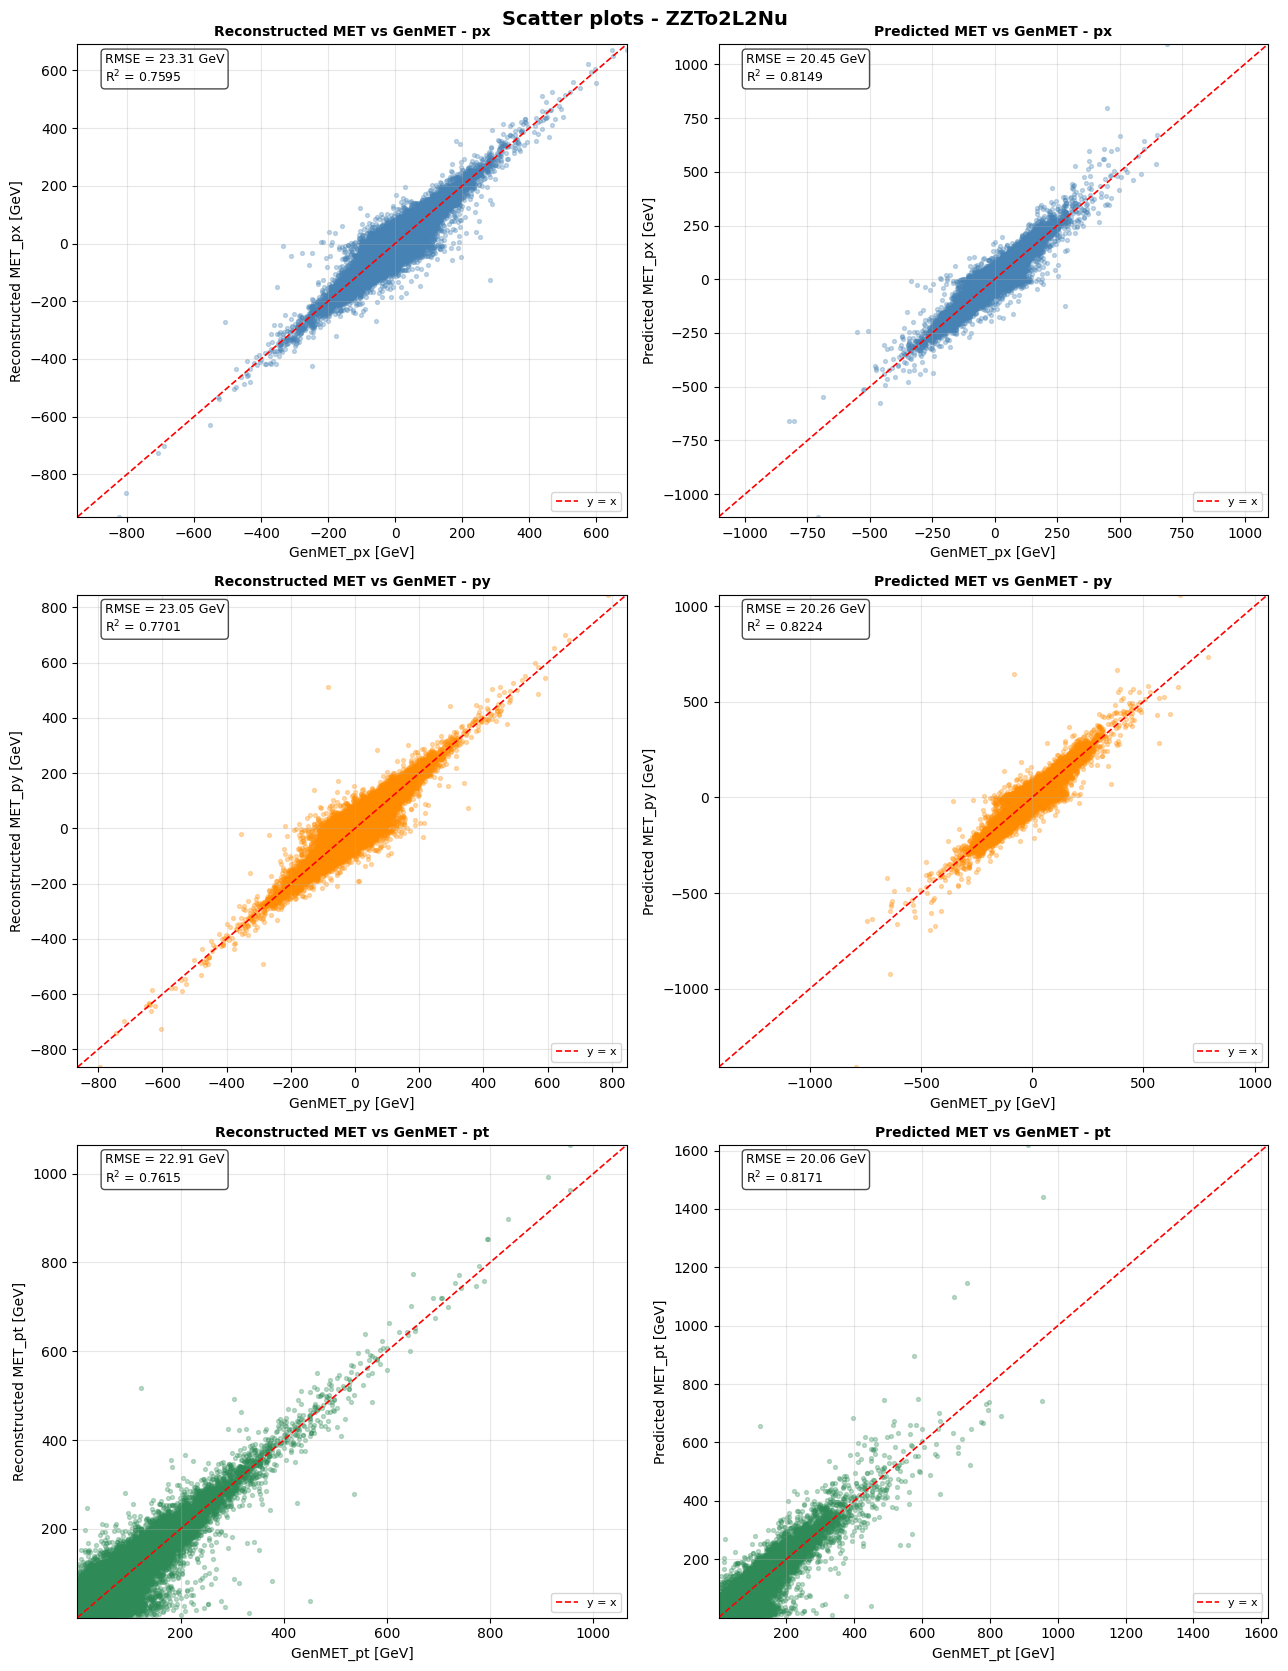


PX - ZZTo2L2Nu
Reconstruction performance for ZZTo2L2Nu:
    RMSE = 23.3111 GeV
    MAE  = 17.5385 GeV
    R²   = 0.7595
    Std(residuals) = 23.1003 GeV
ML model performance for ZZTo2L2Nu:
    RMSE = 20.4481 GeV
    MAE  = 14.8153 GeV
    R²   = 0.8149
    Std(residuals) = 20.4095 GeV
Performance improvement for ZZTo2L2Nu:
    DELTA_RMSE = +2.8630 GeV (+12.28%)
    DELTA_MAE  = +2.7232 GeV (+15.53%)
    DELTA_R²   = +0.0555     (+7.30%)
    DELTA_STD  = 2.6908    +11.65%

PY - ZZTo2L2Nu
Reconstruction performance for ZZTo2L2Nu:
    RMSE = 23.0469 GeV
    MAE  = 17.3062 GeV
    R²   = 0.7701
    Std(residuals) = 23.0441 GeV
ML model performance for ZZTo2L2Nu:
    RMSE = 20.2551 GeV
    MAE  = 14.6322 GeV
    R²   = 0.8224
    Std(residuals) = 20.2545 GeV
Performance improvement for ZZTo2L2Nu:
    DELTA_RMSE = +2.7918 GeV (+12.11%)
    DELTA_MAE  = +2.6741 GeV (+15.45%)
    DELTA_R²   = +0.0523     (+6.80%)
    DELTA_STD  = 2.7896    +12.11%

PT - ZZTo2L2Nu
Reconstruction performance f

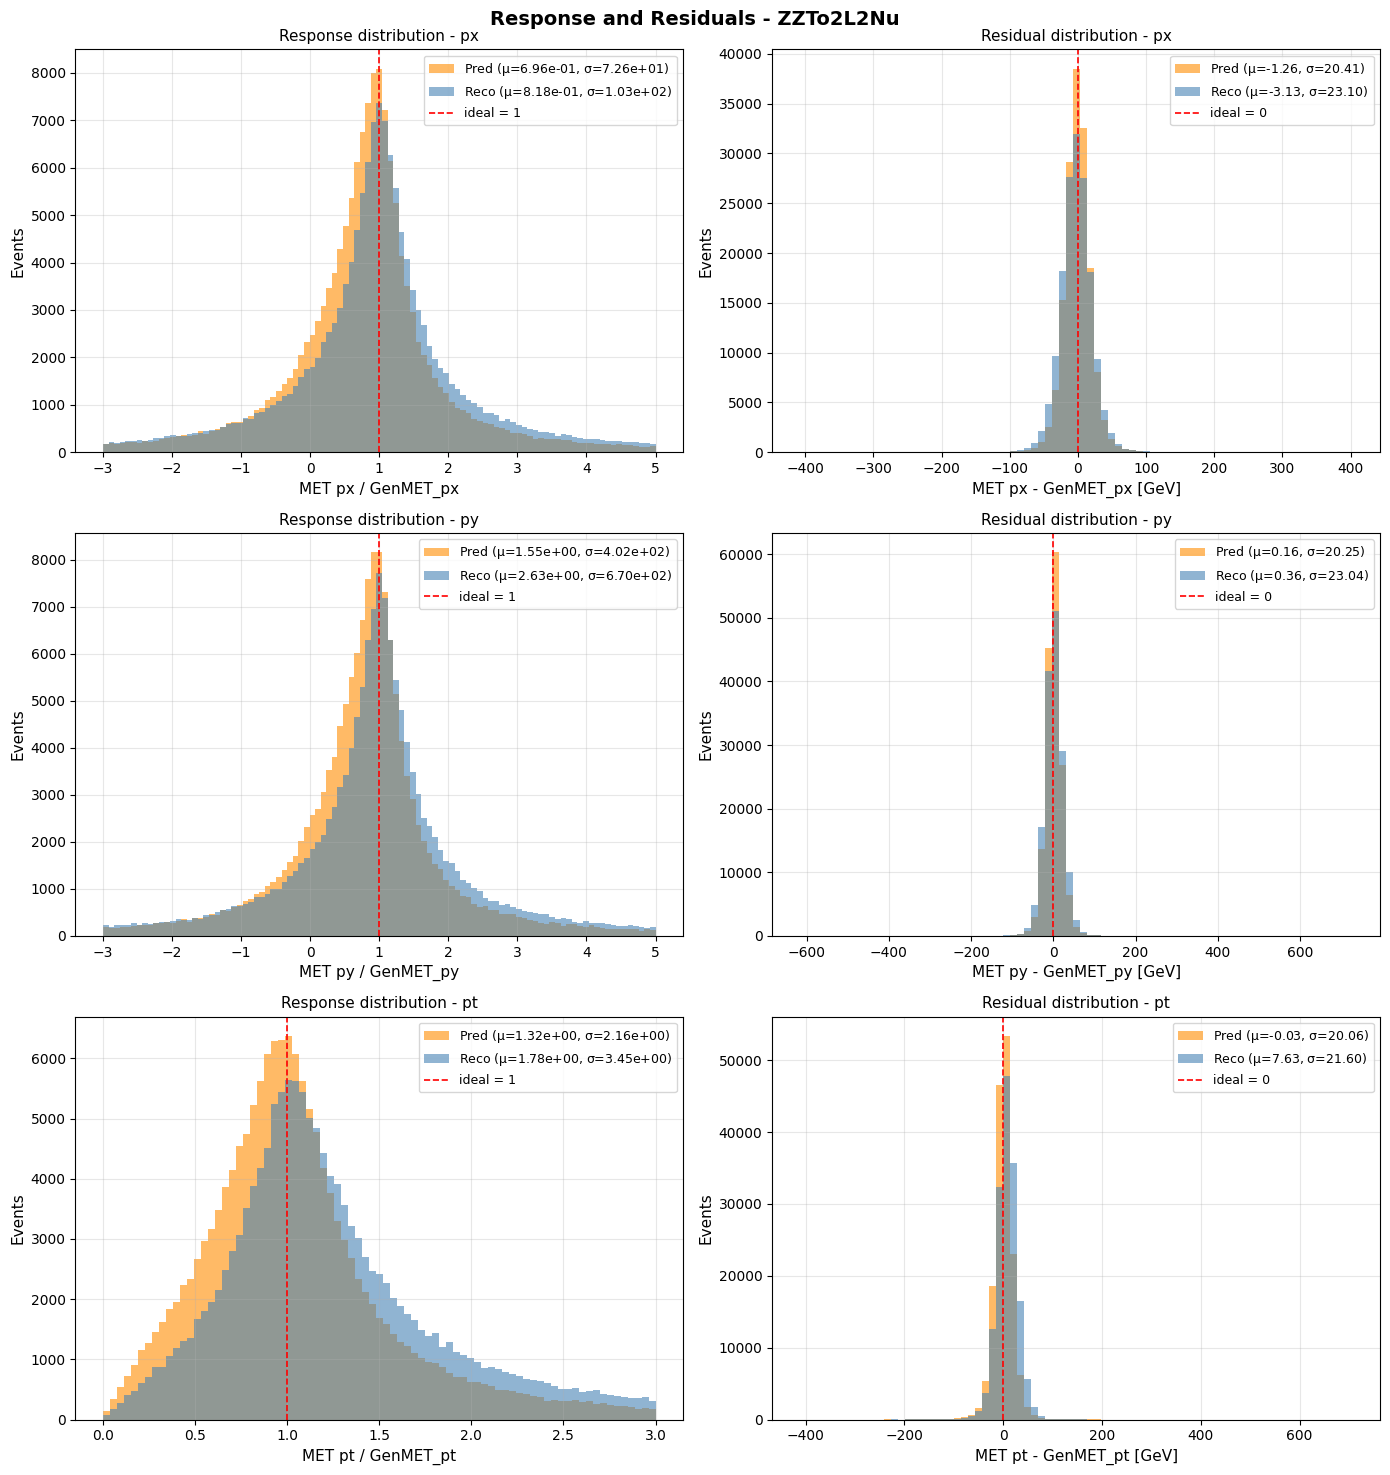

Residual Profile Histogram specifics:
    [px] bin_width=10.0 GeV | range [-350, 320] GeV | n_bins=153
    [py] bin_width=10.0 GeV | range [-320, 320] GeV | n_bins=159
  Excluding GenMET_pt <= 50.0 GeV: 103,677 events removed
    [pt] bin_width=10.0 GeV | range [50, 490] GeV | n_bins=91


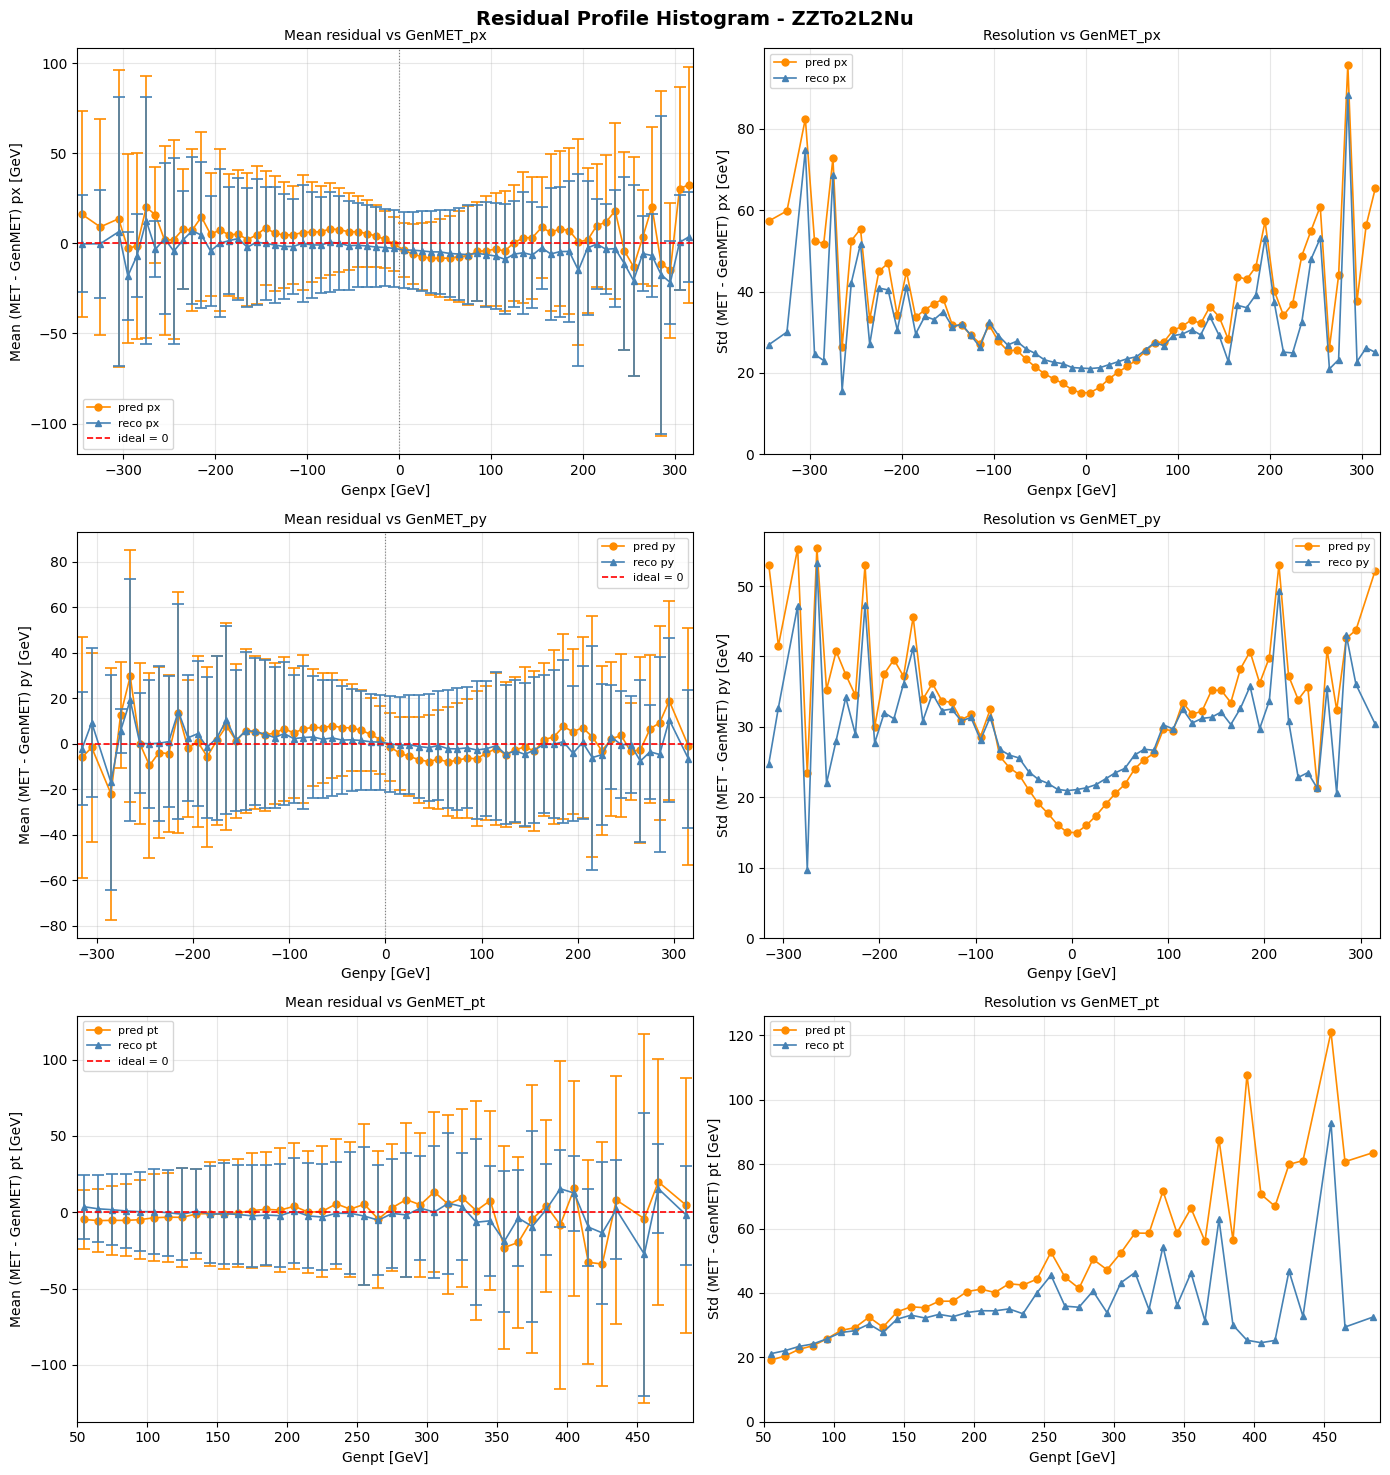

Response Profile Histogram specifics:
  Excluding |GenMET_px| <= 10.0 GeV: 46,724 events removed
    [px] bin_width=10.0 GeV | range [-350, 320] GeV | n_bins=153
  Excluding |GenMET_py| <= 10.0 GeV: 47,051 events removed
    [py] bin_width=10.0 GeV | range [-320, 320] GeV | n_bins=159
  Excluding |GenMET_pt| <= 50.0 GeV: 103,677 events removed
    [pt] bin_width=10.0 GeV | range [50, 490] GeV | n_bins=91


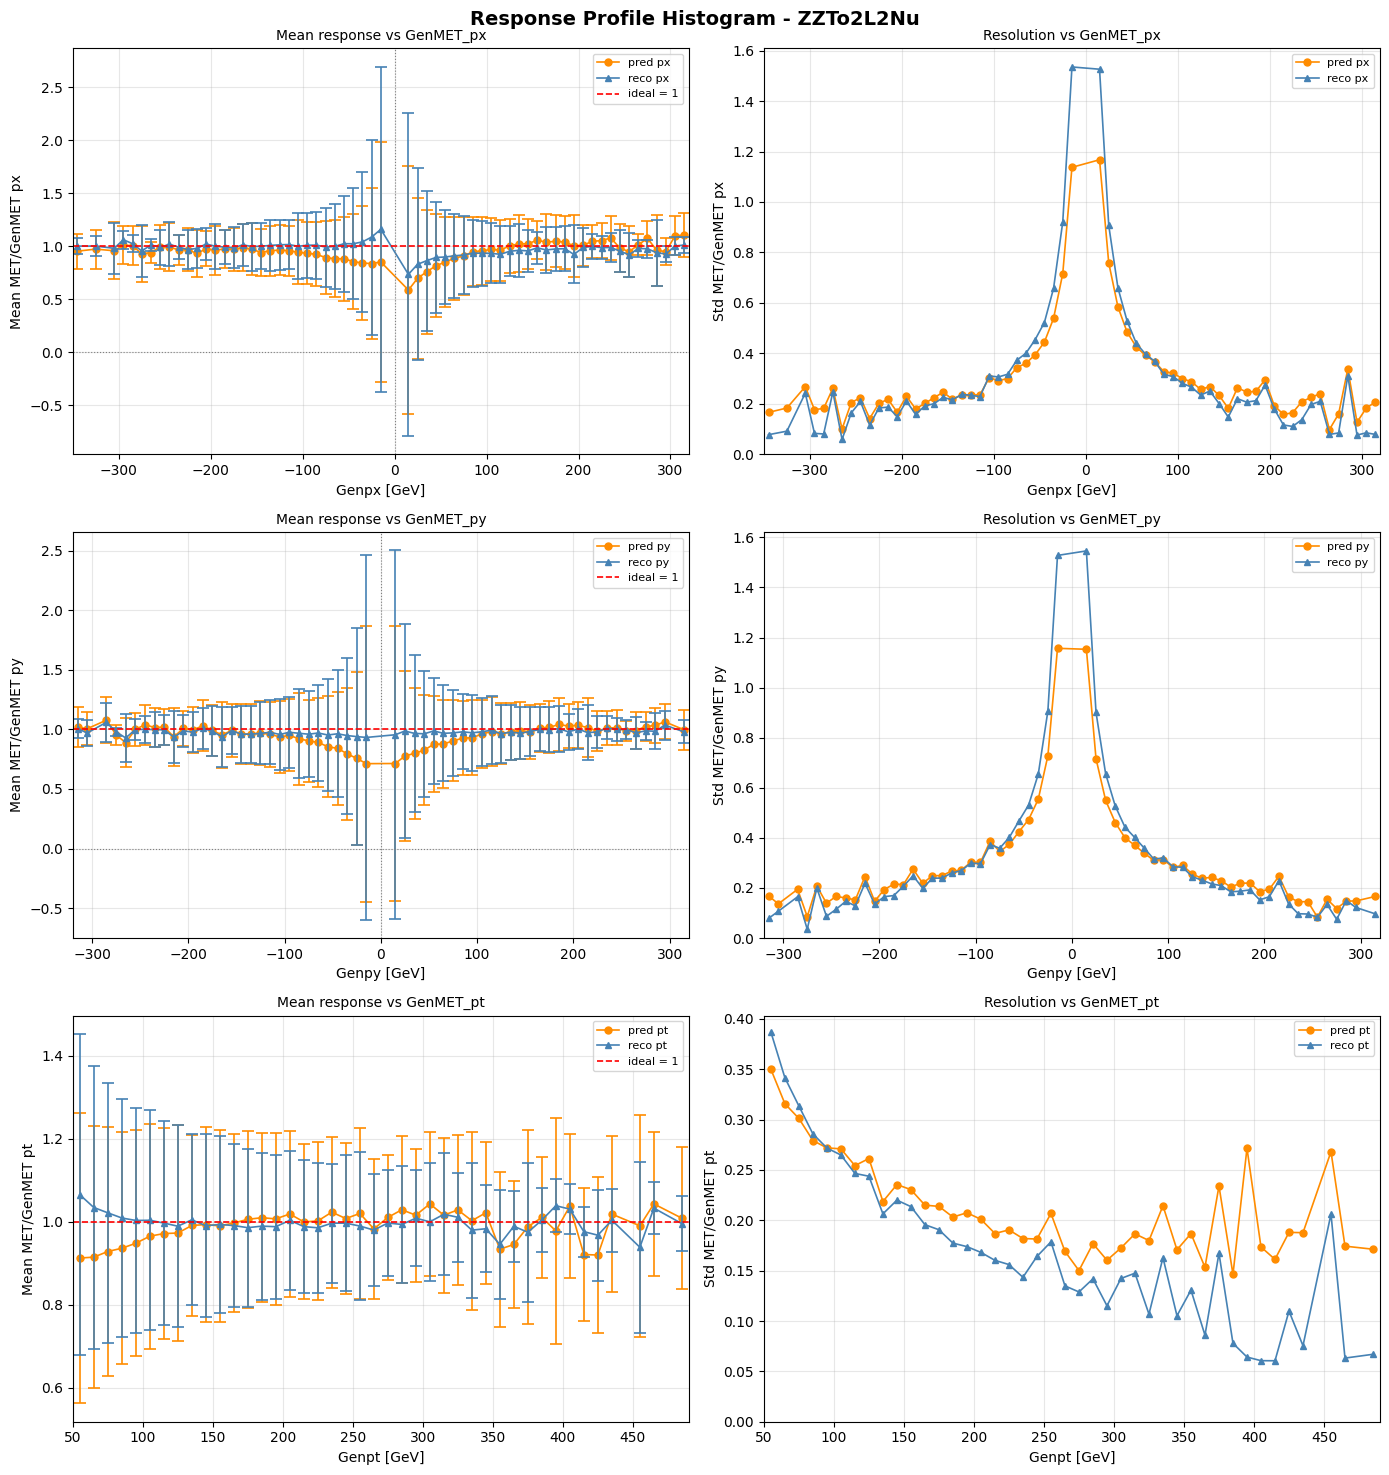

  Excluding GenMET_pt < 0.0 GeV: 0 events removed.
  Plotting up to 490 GeV.
  Last bin with >= 10 events: [480, 490] GeV, n=14


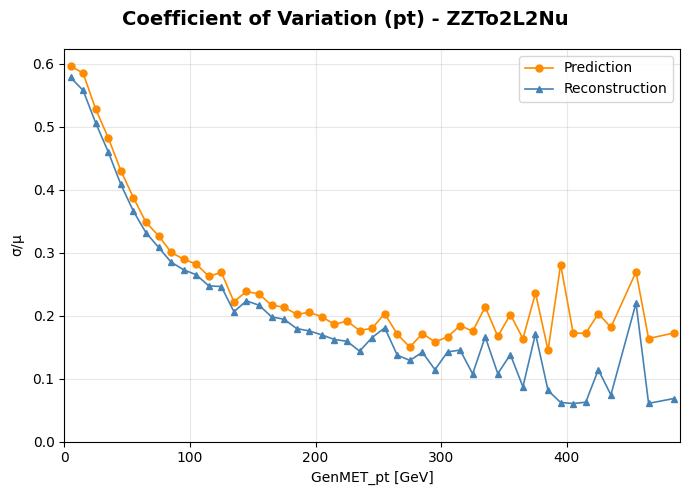

Coefficient of Variation comparison (pt):
    Bins compared: 47 / 96
    Average improvement weighted by events count: -0.0214
    Fraction of bins where prediction improves CoV: 0.0%
    Best bin: [240, 250] GeV -> Δ=-0.0148 (-9.0%)
    Worst bin: [390, 400] GeV -> Δ=-0.2190 (-353.2%)


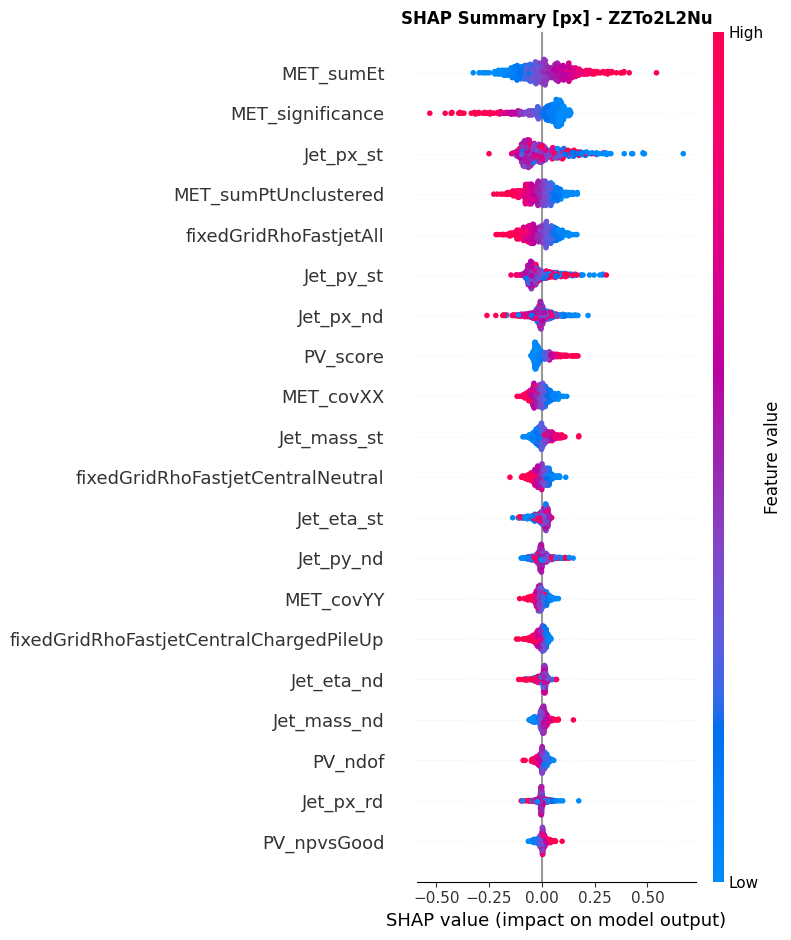


  Feature importance (mean |SHAP|) [px] for ZZTo2L2Nu:
    MET_sumEt                           0.1018
    MET_significance                    0.0819
    Jet_px_st                           0.0800
    MET_sumPtUnclustered                0.0553
    fixedGridRhoFastjetAll              0.0544
    Jet_py_st                           0.0507
    Jet_px_nd                           0.0370
    PV_score                            0.0310
    MET_covXX                           0.0308
    Jet_mass_st                         0.0268
    fixedGridRhoFastjetCentralNeutral   0.0258
    Jet_eta_st                          0.0235
    Jet_py_nd                           0.0223
    MET_covYY                           0.0191
    fixedGridRhoFastjetCentralChargedPileUp 0.0178
    Jet_eta_nd                          0.0169
    Jet_mass_nd                         0.0161
    PV_ndof                             0.0149
    Jet_px_rd                           0.0139
    PV_npvsGood                         0.0138


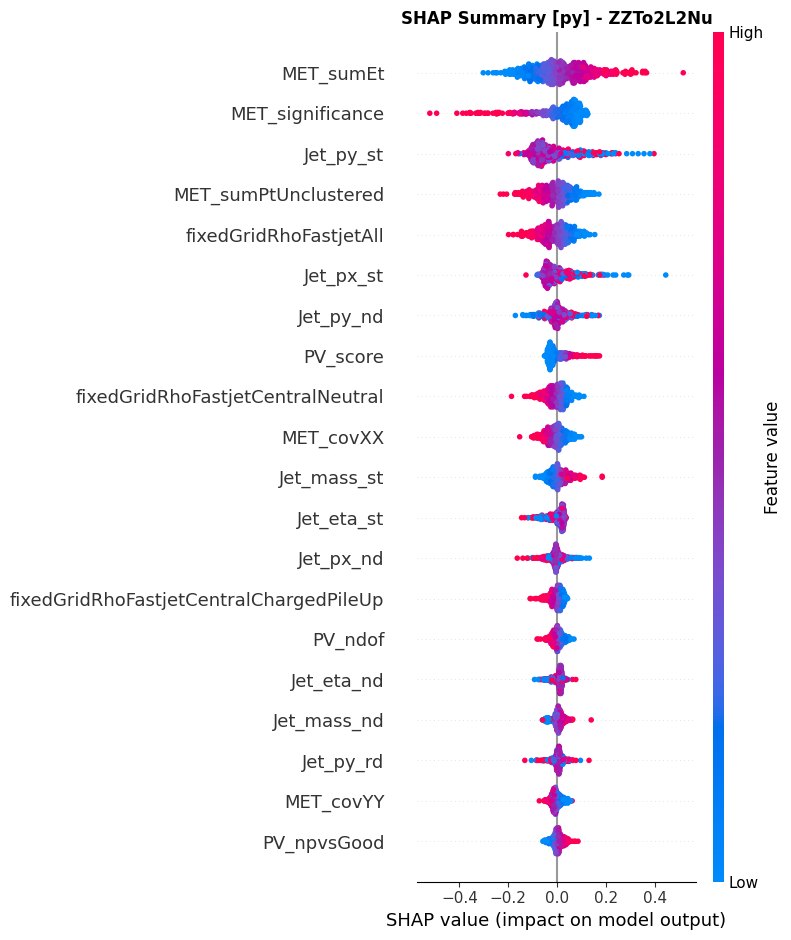


  Feature importance (mean |SHAP|) [py] for ZZTo2L2Nu:
    MET_sumEt                           0.0948
    MET_significance                    0.0763
    Jet_py_st                           0.0757
    MET_sumPtUnclustered                0.0550
    fixedGridRhoFastjetAll              0.0483
    Jet_px_st                           0.0438
    Jet_py_nd                           0.0328
    PV_score                            0.0308
    fixedGridRhoFastjetCentralNeutral   0.0305
    MET_covXX                           0.0302
    Jet_mass_st                         0.0275
    Jet_eta_st                          0.0243
    Jet_px_nd                           0.0214
    fixedGridRhoFastjetCentralChargedPileUp 0.0180
    PV_ndof                             0.0166
    Jet_eta_nd                          0.0166
    Jet_mass_nd                         0.0163
    Jet_py_rd                           0.0156
    MET_covYY                           0.0150
    PV_npvsGood                         0.0147


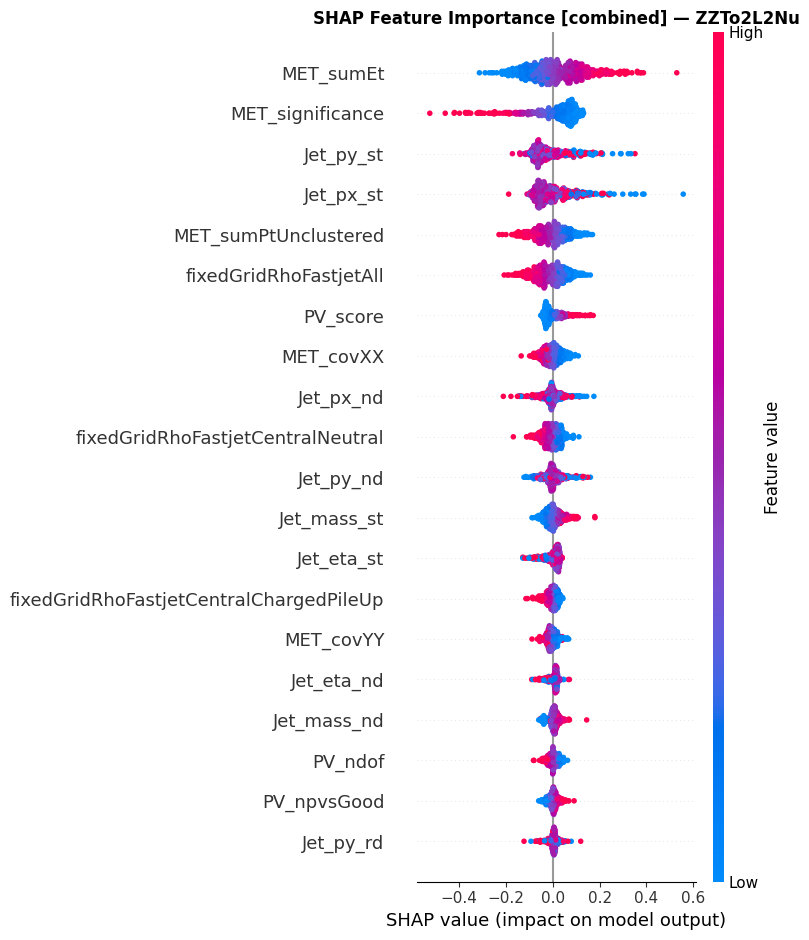


  Feature importance (mean |SHAP|) [combined] for ZZTo2L2Nu:
    MET_sumEt                           0.0983
    MET_significance                    0.0791
    Jet_py_st                           0.0630
    Jet_px_st                           0.0616
    MET_sumPtUnclustered                0.0551
    fixedGridRhoFastjetAll              0.0514
    PV_score                            0.0309
    MET_covXX                           0.0305
    Jet_px_nd                           0.0292
    fixedGridRhoFastjetCentralNeutral   0.0281
    Jet_py_nd                           0.0274
    Jet_mass_st                         0.0272
    Jet_eta_st                          0.0237
    fixedGridRhoFastjetCentralChargedPileUp 0.0179
    MET_covYY                           0.0171
    Jet_eta_nd                          0.0165
    Jet_mass_nd                         0.0162
    PV_ndof                             0.0157
    PV_npvsGood                         0.0141
    Jet_py_rd                           0

In [18]:
EVENT      = "ZZTo2L2Nu"
PRED_FILE = f"predictions_testing_pxpy_{EVENT}.parquet"
MODEL_DIR = "."

# Reconstructed/Predicted MET vs GenMET
(pred_px, pred_py, pred_pt,
    true_px, true_py, true_pt,
    reco_px, reco_py, reco_pt) = load_predictions(EVENT)

# Scatterplots
_scatterplots(
            pred_px, pred_py, pred_pt,
            true_px, true_py, true_pt,
            reco_px, reco_py, reco_pt,
            event=EVENT,
        )

# Performance metrics
_compute_metrics(
            pred_px, pred_py, pred_pt,
            true_px, true_py, true_pt,
            reco_px, reco_py, reco_pt,
            event=EVENT,
        )

# Response and residual histograms
_response_and_residual_plots(
            pred_px, pred_py, pred_pt,
            true_px, true_py, true_pt,
            reco_px, reco_py, reco_pt,
            event=EVENT
        )

# Profile histogram residuals
_profile_histogram_residuals(
            pred_px, pred_py, pred_pt,
            true_px, true_py, true_pt,
            reco_px, reco_py, reco_pt,
            event=EVENT, bin_width = 10.0,
            min_counts = 10, min_Gen = 50.0
        )

# Profile histogram response
_profile_histogram_response(
            pred_px, pred_py, pred_pt,
            true_px, true_py, true_pt,
            reco_px, reco_py, reco_pt,
            event=EVENT, bin_width= 10.0,
            min_counts = 10, min_Gen = 50.0,
            min_Gen_pxpy = 10.0
        )

# Profile histogram CoV
_profile_coefficient_of_variation(
            pred_pt, true_pt, reco_pt,
            event=EVENT, bin_width = 10.0,
            min_counts = 10, min_Gen = 0.0
        )

# SHAP
model, scaler, run_summary = load_model_and_scaler(MODEL_DIR)
_feature_importance_shap(model, EVENT)